# Comprensión y análisis exploratorio de datos

Este notebook desarrolla la comprensión, validación y análisis exploratorio del conjunto de datos utilizado para predecir el pago a tiempo de los préstamos.

El análisis incluye:

- Exploración inicial y caracterización de las variables.
- Revisión y unificación de valores nulos.
- Validación y corrección de tipos de datos.
- Identificación de variables irrelevantes.
- Análisis univariable, bivariable y multivariable.
- Identificación de posibles transformaciones y atributos derivados.
- Definición preliminar de reglas para validar los datos.

In [1]:
# Librerías para manipulación, análisis y visualización de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Configuración visual
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Carga del conjunto de datos

ruta_base = Path.cwd() / "Base_de_datos.xlsx"

if not ruta_base.exists():
    ruta_base = Path.cwd().parent / "Base_de_datos.xlsx"

df = pd.read_excel(ruta_base)

print("Ruta utilizada:", ruta_base)
print("Dimensiones de la base:", df.shape)
display(df.head())

Ruta utilizada: c:\Users\USUARIO\Documents\Programación\Henry\Data sciencie\Módulo 5\Proyecto_integrador_M5\mlops_pipeline\Base_de_datos.xlsx
Dimensiones de la base: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,7,2024-12-21 11:31:35,3692160.0,10,42,Independiente,8000000,2500000,341296,88.768094,695.0,10,5,0.0,51258.0,51258.0,0.0,5,0,0,908526.0,Estable,1
1,4,2025-04-22 09:47:35,840000.0,6,60,Empleado,3000000,2000000,124876,95.227787,789.0,3,1,0.0,8673.0,8673.0,0.0,0,0,2,939017.0,Creciente,1
2,9,2026-01-08 12:22:40,5974028.4,10,36,Independiente,4036000,829000,529554,47.613894,740.0,4,5,0.0,18702.0,18702.0,0.0,3,0,0,NaN,NaN,0
3,4,2025-08-04 12:04:10,1671240.0,6,48,Empleado,1524547,498000,252420,95.227787,837.0,4,4,0.0,15782.0,15782.0,0.0,3,0,0,1536193.0,Creciente,1
4,9,2025-04-26 11:24:26,2781636.0,11,44,Empleado,5000000,4000000,217037,95.227787,771.0,4,6,0.0,204804.0,204804.0,0.0,3,0,1,933473.0,Creciente,1


## 1. Exploración inicial del conjunto de datos

En esta sección se examinan las dimensiones, los tipos de variables y las principales características estadísticas del conjunto de datos antes de realizar cualquier transformación.

In [3]:
# Resumen de la estructura del conjunto de datos

print(f"Cantidad de registros: {df.shape[0]}")
print(f"Cantidad de variables: {df.shape[1]}")
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"Total de valores nulos: {df.isna().sum().sum()}")

print("\nDistribución de tipos de datos:")
display(df.dtypes.value_counts().to_frame(name="cantidad"))

Cantidad de registros: 10763
Cantidad de variables: 23
Filas duplicadas: 0
Total de valores nulos: 7175

Distribución de tipos de datos:


,cantidad
int64,12
float64,8
datetime64[us],1
str,1
object,1


### 1.1 Resumen estadístico de las variables

Se analizan las medidas descriptivas de las variables numéricas y la distribución general de las variables categóricas. Esto permite detectar valores extremos, escalas diferentes, categorías poco frecuentes y posibles inconsistencias.

In [4]:
# Resumen estadístico de las variables numéricas

resumen_numerico = df.describe(include=[np.number]).T

display(
    resumen_numerico.style.format({
        "count": "{:.0f}",
        "mean": "{:.2f}",
        "std": "{:.2f}",
        "min": "{:.2f}",
        "25%": "{:.2f}",
        "50%": "{:.2f}",
        "75%": "{:.2f}",
        "max": "{:.2f}"
    })
)

,count,mean,std,min,25%,50%,75%,max
tipo_credito,10763,5.41,2.34,4.00,4.00,4.00,9.00,68.00
capital_prestado,10763,2434315.00,1909642.76,360000.00,1224831.00,1921920.00,3084840.00,41444152.80
plazo_meses,10763,10.58,6.63,2.00,6.00,10.00,12.00,90.00
edad_cliente,10763,43.95,15.06,19.00,33.00,42.00,53.00,123.00
salario_cliente,10763,17216431.46,355476717.60,0.00,2000000.00,3000000.00,4875808.00,22000000000.00
total_otros_prestamos,10763,6238869.65,118418316.94,0.00,500000.00,1000000.00,2000000.00,6787675263.00
cuota_pactada,10763,243617.41,210493.69,23944.00,121041.50,182863.00,287833.50,3816752.00
puntaje,10763,91.17,16.47,-38.01,95.23,95.23,95.23,95.23
puntaje_datacredito,10757,780.79,104.88,-7.00,757.00,791.00,825.00,999.00
cant_creditosvigentes,10763,5.73,3.98,0.00,3.00,5.00,8.00,62.00


#### Interpretación inicial del resumen numérico

El resumen estadístico revela diferencias importantes de escala y posibles inconsistencias que deberán analizarse antes del modelado.

Se observan valores potencialmente anómalos, como una edad máxima de 123 años y un puntaje de Datacrédito mínimo de -7. También aparecen máximos muy alejados de las medianas en variables monetarias como `salario_cliente`, `total_otros_prestamos`, `capital_prestado` y algunos saldos de deuda. Estas diferencias sugieren distribuciones asimétricas y posibles valores extremos, aunque todavía no permiten concluir que se trate de errores.

La variable `puntaje` requiere una revisión particular, ya que sus percentiles 25, 50 y 75 coinciden en 95,23, mientras que presenta valores mínimos negativos. Esto podría indicar una fuerte concentración, valores predeterminados o una regla de cálculo específica.

Por otra parte, la media de `Pago_atiempo` es aproximadamente 0,95. Al tratarse de una variable binaria, esto anticipa un marcado desbalance de clases, con una amplia mayoría de préstamos pagados a tiempo. Esta característica deberá considerarse al seleccionar las métricas de evaluación y las estrategias de modelado.

Los diferentes valores de `count` también confirman la presencia de datos faltantes en varias variables. Todos estos casos serán estudiados mediante análisis de frecuencias, distribuciones y reglas de validación, sin eliminar observaciones de manera automática.

In [5]:
# Resumen estadístico de las variables categóricas

resumen_categorico = df.describe(include=["object"]).T

display(resumen_categorico)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_15976\1513205465.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  resumen_categorico = df.describe(include=["object"]).T


,count,unique,top,freq
tipo_laboral,10763,2,Empleado,6754
tendencia_ingresos,7831,46,Creciente,5294


#### Interpretación inicial del resumen categórico

La variable `tipo_laboral` está completa y contiene únicamente dos categorías. La categoría más frecuente es `Empleado`, con 6.754 registros, por lo que posteriormente se analizará la distribución entre ambas clases.

La variable `tendencia_ingresos` contiene 7.831 valores informados y, por diferencia respecto de los 10.763 registros totales, presenta 2.932 valores faltantes. Aunque la categoría más frecuente es `Creciente`, con 5.294 registros, se identifican 46 valores únicos.

Esta cantidad de categorías resulta elevada para una variable que describe una tendencia. Por ello, será necesario revisar sus frecuencias y valores exactos para detectar posibles diferencias de escritura, espacios adicionales, uso inconsistente de mayúsculas, categorías poco frecuentes o textos utilizados para representar datos faltantes.

In [6]:
# Frecuencias de las variables categóricas

for columna in ["tipo_laboral", "tendencia_ingresos"]:
    print(f"\n{'=' * 60}")
    print(f"Distribución de: {columna}")
    print(f"{'=' * 60}")

    frecuencias = (
        df[columna]
        .fillna("<VALOR_NULO>")
        .value_counts(dropna=False)
        .rename_axis("categoria")
        .reset_index(name="frecuencia")
    )

    frecuencias["porcentaje"] = (
        frecuencias["frecuencia"] / len(df) * 100
    ).round(2)

    display(frecuencias)


Distribución de: tipo_laboral


,categoria,frecuencia,porcentaje
0,Empleado,6754,62.75
1,Independiente,4009,37.25



Distribución de: tendencia_ingresos


,categoria,frecuencia,porcentaje
0,Creciente,5294,49.19
1,<VALOR_NULO>,2932,27.24
2,Decreciente,1291,11.99
3,Estable,1188,11.04
4,0,7,0.07
5,8315,6,0.06
6,1000000,4,0.04
7,9147,2,0.02
8,158042,1,0.01
9,3978,1,0.01


#### Hallazgos en las variables categóricas

La variable `tipo_laboral` presenta una estructura consistente, con dos categorías: `Empleado` e `Independiente`.

En cambio, `tendencia_ingresos` presenta una inconsistencia relevante. Además de las categorías esperadas `Creciente`, `Decreciente` y `Estable`, contiene numerosos valores numéricos aislados. La incorporación de los valores nulos como `<VALOR_NULO>` produce 47 grupos en la tabla de frecuencias: 46 valores únicos originalmente informados y un grupo adicional correspondiente a los datos faltantes.

Los valores numéricos no representan tendencias de ingresos válidas y podrían proceder de errores de registro, desplazamientos de datos o contaminación con información perteneciente a otra variable. Por ello, serán identificados y cuantificados como valores anómalos antes de decidir su tratamiento. No se los transformará automáticamente en ninguna de las categorías válidas.

In [7]:
# Validación de las categorías de tendencia_ingresos

categorias_validas = ["Creciente", "Decreciente", "Estable"]

mascara_nulos = df["tendencia_ingresos"].isna()
mascara_validos = df["tendencia_ingresos"].isin(categorias_validas)
mascara_anomalos = ~mascara_nulos & ~mascara_validos

print("Categorías válidas:", categorias_validas)
print(f"Valores válidos: {mascara_validos.sum()}")
print(f"Valores nulos: {mascara_nulos.sum()}")
print(f"Valores anómalos: {mascara_anomalos.sum()}")
print(
    "Comprobación del total:",
    mascara_validos.sum() + mascara_nulos.sum() + mascara_anomalos.sum()
)

print("\nFrecuencias de los valores anómalos:")
display(
    df.loc[mascara_anomalos, "tendencia_ingresos"]
      .value_counts(dropna=False)
      .rename_axis("valor_anomalo")
      .reset_index(name="frecuencia")
)

Categorías válidas: ['Creciente', 'Decreciente', 'Estable']
Valores válidos: 7773
Valores nulos: 2932
Valores anómalos: 58
Comprobación del total: 10763

Frecuencias de los valores anómalos:


,valor_anomalo,frecuencia
0,0,7
1,8315,6
2,1000000,4
3,9147,2
4,158042,1
5,3978,1
6,168750,1
7,-28589,1
8,-566272,1
9,24702,1


#### Validación de `tendencia_ingresos`

La validación contra las categorías esperadas (`Creciente`, `Decreciente` y `Estable`) permitió clasificar los 10.763 registros de la siguiente manera:

- **7.773 valores válidos**
- **2.932 valores nulos**
- **58 valores anómalos**

Los valores anómalos se distribuyen entre 43 valores diferentes y están representados principalmente por números, como `0`, `8315` y `1000000`. Por lo tanto, no corresponden a variantes de escritura de las categorías válidas.

Aunque estos resultados confirman una inconsistencia semántica, todavía no permiten establecer su origen. Antes de decidir su tratamiento, se inspeccionarán las filas completas afectadas para evaluar si existe algún patrón relacionado con otras variables.

In [8]:
# Inspección de las filas con valores anómalos en tendencia_ingresos

columnas_inspeccion = [
    "tendencia_ingresos",
    "salario_cliente",
    "promedio_ingresos_datacredito",
    "total_otros_prestamos",
    "capital_prestado",
    "tipo_laboral",
    "Pago_atiempo"
]

filas_tendencia_anomala = (
    df.loc[mascara_anomalos, columnas_inspeccion]
      .copy()
)

print("Cantidad de filas inspeccionadas:", len(filas_tendencia_anomala))
display(filas_tendencia_anomala)

Cantidad de filas inspeccionadas: 58


,tendencia_ingresos,salario_cliente,promedio_ingresos_datacredito,total_otros_prestamos,capital_prestado,tipo_laboral,Pago_atiempo
157,8315,4000000,939017.0,1000000,821208.0,Empleado,1
168,0,5000000,1200000.0,2000000,1604400.0,Independiente,1
440,158042,44707750,28878675.0,8000000,6333012.0,Empleado,1
486,3978,6000000,1562215.0,3500000,5854800.0,Independiente,1
705,9147,3100000,1000000.0,2000000,2860207.2,Empleado,1
1185,8315,2990000,977131.0,4048000,4243200.0,Independiente,1
1188,168750,2900000,2550000.0,1400000,1973880.0,Empleado,1
1898,-28589,5000000,5425531.0,2000000,1482264.0,Empleado,1
2027,8315,1500000,916148.0,700000,2111641.2,Independiente,1
2038,1000000,1500000,917014.0,500000,2251081.2,Independiente,1


In [9]:
# Búsqueda de coincidencias entre los valores anómalos y otras variables numéricas

columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()

resultados_coincidencias = []

for indice in df.index[mascara_anomalos]:
    valor_anomalo = pd.to_numeric(
        df.loc[indice, "tendencia_ingresos"],
        errors="coerce"
    )

    columnas_coincidentes = []

    if pd.notna(valor_anomalo):
        for columna in columnas_numericas:
            valor_columna = df.loc[indice, columna]

            if pd.notna(valor_columna) and np.isclose(
                float(valor_anomalo),
                float(valor_columna)
            ):
                columnas_coincidentes.append(columna)

    resultados_coincidencias.append({
        "indice": indice,
        "valor_anomalo": valor_anomalo,
        "columnas_coincidentes": (
            ", ".join(columnas_coincidentes)
            if columnas_coincidentes
            else "Sin coincidencias"
        )
    })

coincidencias_tendencia = pd.DataFrame(resultados_coincidencias)

print("Cantidad total de casos:", len(coincidencias_tendencia))
print(
    "Casos con coincidencia en la misma fila:",
    (coincidencias_tendencia["columnas_coincidentes"] != "Sin coincidencias").sum()
)
print(
    "Casos sin coincidencias:",
    (coincidencias_tendencia["columnas_coincidentes"] == "Sin coincidencias").sum()
)

display(coincidencias_tendencia)

Cantidad total de casos: 58
Casos con coincidencia en la misma fila: 8
Casos sin coincidencias: 50


,indice,valor_anomalo,columnas_coincidentes
0,157,8315,Sin coincidencias
1,168,0,"saldo_mora, saldo_mora_codeudor, creditos_sect..."
2,440,158042,Sin coincidencias
3,486,3978,Sin coincidencias
4,705,9147,Sin coincidencias
5,1185,8315,Sin coincidencias
6,1188,168750,Sin coincidencias
7,1898,-28589,Sin coincidencias
8,2027,8315,Sin coincidencias
9,2038,1000000,Sin coincidencias


In [10]:
# Revisión de los casos con coincidencias en la misma fila

casos_con_coincidencia = coincidencias_tendencia.loc[
    coincidencias_tendencia["columnas_coincidentes"] != "Sin coincidencias"
].copy()

pd.set_option("display.max_colwidth", None)

display(casos_con_coincidencia)

,indice,valor_anomalo,columnas_coincidentes
1,168,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo"
21,4761,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorFinanciero, creditos_sectorCooperativo, creditos_sectorReal"
26,5709,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo"
28,6071,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo, creditos_sectorReal"
29,6088,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo"
30,6276,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo"
48,8494,1000000,total_otros_prestamos
51,8571,0,"saldo_mora, saldo_mora_codeudor, creditos_sectorCooperativo"


#### Búsqueda de coincidencias con otras variables

La comparación de los 58 valores anómalos de `tendencia_ingresos` con todas las variables numéricas de sus respectivas filas produjo los siguientes resultados:

- **8 casos presentan alguna coincidencia numérica en la misma fila.**
- **50 casos no coinciden con ninguna variable numérica de la misma observación.**

La presencia de una coincidencia no demuestra necesariamente un desplazamiento o una copia de datos. Algunos valores, especialmente el cero, pueden aparecer legítimamente en varias variables financieras y generar coincidencias casuales.

Por lo tanto, no se observa hasta el momento un patrón general que permita reconstruir la categoría original de `tendencia_ingresos`. Los casos coincidentes se revisarán individualmente antes de establecer el tratamiento definitivo de los 58 valores anómalos.

#### Conclusión sobre las coincidencias encontradas

La revisión individual de los ocho casos con coincidencias numéricas no permite identificar un patrón general de desplazamiento o copia de datos.

En siete casos, el valor anómalo es cero y coincide con variables financieras o indicadores sectoriales que también presentan legítimamente ese valor. Por esta razón, las coincidencias pueden considerarse circunstanciales.

Solo se identificó una coincidencia no nula: en el índice 8494, el valor `1000000` coincide con `total_otros_prestamos`. Sin embargo, se trata de un caso aislado y no aporta información para determinar si la categoría original de `tendencia_ingresos` era `Creciente`, `Decreciente` o `Estable`.

En consecuencia, los 58 valores anómalos no pueden reconstruirse de manera confiable. Se reclasificarán como valores faltantes, sin eliminar las observaciones afectadas. La estrategia de imputación de esta variable se definirá posteriormente, evitando utilizar la variable objetivo para prevenir fuga de información.

In [11]:
# Creación de una copia de trabajo para la limpieza

df_limpio = df.copy()

nulos_antes = df_limpio["tendencia_ingresos"].isna().sum()

df_limpio.loc[mascara_anomalos, "tendencia_ingresos"] = np.nan

nulos_despues = df_limpio["tendencia_ingresos"].isna().sum()
categorias_restantes = sorted(
    df_limpio["tendencia_ingresos"].dropna().unique()
)

print("Valores nulos antes de la corrección:", nulos_antes)
print("Valores anómalos reclasificados:", mascara_anomalos.sum())
print("Valores nulos después de la corrección:", nulos_despues)
print("Categorías no nulas restantes:", categorias_restantes)
print("Dimensiones de la base de trabajo:", df_limpio.shape)

Valores nulos antes de la corrección: 2932
Valores anómalos reclasificados: 58
Valores nulos después de la corrección: 2990
Categorías no nulas restantes: ['Creciente', 'Decreciente', 'Estable']
Dimensiones de la base de trabajo: (10763, 23)


#### Reclasificación de valores anómalos

Se creó `df_limpio` como copia de trabajo, conservando `df` sin modificaciones para mantener disponible la base original.

Los 58 valores numéricos anómalos de `tendencia_ingresos` fueron reclasificados como valores faltantes, ya que no fue posible reconstruir de manera confiable su categoría original. Como resultado, la variable pasó de 2.932 a **2.990 valores nulos**.

Después de la corrección, las únicas categorías no nulas restantes son `Creciente`, `Decreciente` y `Estable`. La operación no eliminó registros ni modificó las dimensiones del conjunto, que continúa teniendo **10.763 filas y 23 columnas**.

## 2. Análisis y tratamiento de valores faltantes

En esta sección se identificará la cantidad y proporción de valores faltantes por variable. También se estudiará si la ausencia de datos presenta patrones relacionados entre columnas antes de seleccionar una estrategia de tratamiento.

Las decisiones de imputación se establecerán considerando el significado de cada variable y evitando utilizar información de `Pago_atiempo`, con el objetivo de prevenir fuga de información hacia el modelo.

In [12]:
# Resumen de valores faltantes por variable

resumen_nulos = pd.DataFrame({
    "cantidad_nulos": df_limpio.isna().sum(),
    "porcentaje_nulos": (
        df_limpio.isna().mean() * 100
    ).round(2)
})

resumen_nulos = (
    resumen_nulos
    .loc[resumen_nulos["cantidad_nulos"] > 0]
    .sort_values("cantidad_nulos", ascending=False)
)

print("Variables con valores faltantes:", len(resumen_nulos))
print(
    "Total de valores faltantes después de la corrección:",
    df_limpio.isna().sum().sum()
)

display(resumen_nulos)

Variables con valores faltantes: 7
Total de valores faltantes después de la corrección: 7233


,cantidad_nulos,porcentaje_nulos
tendencia_ingresos,2990,27.78
promedio_ingresos_datacredito,2930,27.22
saldo_mora_codeudor,590,5.48
saldo_principal,405,3.76
saldo_mora,156,1.45
saldo_total,156,1.45
puntaje_datacredito,6,0.06


### 2.1 Distribución de los valores faltantes

Después de reclasificar los 58 valores anómalos de `tendencia_ingresos`, se identifican **7.233 valores faltantes** distribuidos entre siete variables.

Las mayores proporciones corresponden a `tendencia_ingresos`, con 2.990 valores faltantes (27,78 %), y `promedio_ingresos_datacredito`, con 2.930 (27,22 %). La similitud entre ambas proporciones podría sugerir un origen relacionado, aunque será necesario comprobar si las ausencias coinciden en los mismos registros.

Las restantes variables presentan proporciones menores: `saldo_mora_codeudor` alcanza un 5,48 %, `saldo_principal` un 3,76 %, y tanto `saldo_mora` como `saldo_total` presentan un 1,45 %. En `puntaje_datacredito` solamente se observan 6 valores faltantes, equivalentes al 0,06 %.

La cantidad de datos ausentes no determina por sí sola el tratamiento adecuado. Antes de imputar o interpretar los nulos como ceros, se analizará su coincidencia entre variables y el significado de cada campo.

In [13]:
# Coincidencia de valores faltantes entre variables

columnas_con_nulos = resumen_nulos.index.tolist()

matriz_coincidencias_nulos = pd.DataFrame(
    index=columnas_con_nulos,
    columns=columnas_con_nulos,
    dtype=int
)

for columna_fila in columnas_con_nulos:
    for columna_columna in columnas_con_nulos:
        matriz_coincidencias_nulos.loc[
            columna_fila,
            columna_columna
        ] = (
            df_limpio[columna_fila].isna()
            & df_limpio[columna_columna].isna()
        ).sum()

matriz_coincidencias_nulos = matriz_coincidencias_nulos.astype(int)

display(matriz_coincidencias_nulos)

,tendencia_ingresos,promedio_ingresos_datacredito,saldo_mora_codeudor,saldo_principal,saldo_mora,saldo_total,puntaje_datacredito
tendencia_ingresos,2990,2930,434,249,155,155,5
promedio_ingresos_datacredito,2930,2930,430,246,154,154,5
saldo_mora_codeudor,434,430,590,405,156,156,6
saldo_principal,249,246,405,405,156,156,6
saldo_mora,155,154,156,156,156,156,6
saldo_total,155,154,156,156,156,156,6
puntaje_datacredito,5,5,6,6,6,6,6


### 2.2 Patrones de coincidencia entre valores faltantes

La matriz de coincidencias muestra que los valores faltantes presentan relaciones estructuradas entre distintas variables.

Los 2.930 registros sin `promedio_ingresos_datacredito` también carecen de `tendencia_ingresos`. Esta última variable contiene 60 ausencias adicionales, de las cuales 58 corresponden a los valores anómalos reclasificados previamente como faltantes.

También se observa un patrón anidado entre las variables de deuda. Los 405 registros sin `saldo_principal` se encuentran dentro de los 590 casos sin `saldo_mora_codeudor`. A su vez, los 156 registros sin `saldo_mora` también carecen de `saldo_total`, `saldo_principal` y `saldo_mora_codeudor`.

Las variables `saldo_mora` y `saldo_total` presentan exactamente 156 valores faltantes y estos coinciden en las mismas observaciones. Esta coincidencia completa sugiere que ambas variables podrían proceder de una misma fuente o depender de un mismo proceso de registro.

Los seis registros sin `puntaje_datacredito` también presentan valores faltantes en las cuatro variables relacionadas con los saldos. Cinco de esos seis casos coinciden, además, con ausencias en las variables de ingresos.

En conjunto, los resultados indican que los valores faltantes no están distribuidos de manera completamente independiente. Podrían reflejar distintos niveles de disponibilidad de información crediticia. Por esta razón, no se asumirán automáticamente como ceros ni se imputarán todavía mediante una única estrategia general.

In [14]:
# Verificación de relaciones entre los valores faltantes

verificaciones_nulos = {
    "promedio_ingresos nulo implica tendencia nula": (
        df_limpio.loc[
            df_limpio["promedio_ingresos_datacredito"].isna(),
            "tendencia_ingresos"
        ].isna().all()
    ),
    
    "saldo_principal nulo implica saldo_mora_codeudor nulo": (
        df_limpio.loc[
            df_limpio["saldo_principal"].isna(),
            "saldo_mora_codeudor"
        ].isna().all()
    ),
    
    "saldo_mora y saldo_total tienen el mismo patrón de nulos": (
        df_limpio["saldo_mora"].isna()
        .equals(df_limpio["saldo_total"].isna())
    ),
    
    "saldo_mora nulo implica saldo_principal nulo": (
        df_limpio.loc[
            df_limpio["saldo_mora"].isna(),
            "saldo_principal"
        ].isna().all()
    )
}

for descripcion, resultado in verificaciones_nulos.items():
    print(f"{descripcion}: {resultado}")

print(
    "\nCasos con tendencia_ingresos nula "
    "pero promedio_ingresos_datacredito informado:",
    (
        df_limpio["tendencia_ingresos"].isna()
        & df_limpio["promedio_ingresos_datacredito"].notna()
    ).sum()
)

promedio_ingresos nulo implica tendencia nula: True
saldo_principal nulo implica saldo_mora_codeudor nulo: True
saldo_mora y saldo_total tienen el mismo patrón de nulos: True
saldo_mora nulo implica saldo_principal nulo: True

Casos con tendencia_ingresos nula pero promedio_ingresos_datacredito informado: 60


### 2.3 Verificación de las relaciones entre valores faltantes

Las comprobaciones lógicas confirman formalmente los patrones identificados en la matriz de coincidencias:

- Cuando `promedio_ingresos_datacredito` está ausente, `tendencia_ingresos` también está ausente.
- Cuando `saldo_principal` está ausente, también falta `saldo_mora_codeudor`.
- `saldo_mora` y `saldo_total` presentan exactamente el mismo patrón de valores faltantes.
- Cuando `saldo_mora` está ausente, también falta `saldo_principal`.

Además, se encontraron **60 registros** con `tendencia_ingresos` ausente pero con `promedio_ingresos_datacredito` informado. De ellos, 58 corresponden a los valores anómalos reclasificados previamente y los otros dos eran valores originalmente faltantes.

Estos resultados confirman que una parte importante de las ausencias está estructurada y probablemente relacionada con la disponibilidad de información crediticia. En consecuencia, los indicadores de ausencia podrían conservar información útil para el modelado y deberán considerarse durante la ingeniería de atributos.

In [15]:
# Identificación de patrones exactos de valores faltantes

patrones_nulos = (
    df_limpio[columnas_con_nulos]
    .isna()
    .astype(int)
    .value_counts()
    .reset_index(name="cantidad_registros")
)

patrones_nulos["porcentaje"] = (
    patrones_nulos["cantidad_registros"] / len(df_limpio) * 100
).round(2)

patrones_nulos.insert(
    0,
    "patron",
    [f"Patrón {numero}" for numero in range(1, len(patrones_nulos) + 1)]
)

print("Cantidad de patrones de ausencia identificados:", len(patrones_nulos))
display(patrones_nulos)

Cantidad de patrones de ausencia identificados: 12


,patron,tendencia_ingresos,promedio_ingresos_datacredito,saldo_mora_codeudor,saldo_principal,saldo_mora,saldo_total,puntaje_datacredito,cantidad_registros,porcentaje
0,Patrón 1,0,0,0,0,0,0,0,7617,70.77
1,Patrón 2,1,1,0,0,0,0,0,2500,23.23
2,Patrón 3,1,1,1,0,0,0,0,184,1.71
3,Patrón 4,0,0,1,1,0,0,0,155,1.44
4,Patrón 5,1,1,1,1,1,1,0,149,1.38
5,Patrón 6,1,1,1,1,0,0,0,92,0.85
6,Patrón 7,1,0,0,0,0,0,0,56,0.52
7,Patrón 8,1,1,1,1,1,1,1,5,0.05
8,Patrón 9,1,0,1,1,0,0,0,2,0.02
9,Patrón 10,1,0,1,1,1,1,0,1,0.01


In [16]:
# Visualización completa de los patrones de ausencia

print(
    patrones_nulos.to_string(
        index=False
    )
)

   patron  tendencia_ingresos  promedio_ingresos_datacredito  saldo_mora_codeudor  saldo_principal  saldo_mora  saldo_total  puntaje_datacredito  cantidad_registros  porcentaje
 Patrón 1                   0                              0                    0                0           0            0                    0                7617       70.77
 Patrón 2                   1                              1                    0                0           0            0                    0                2500       23.23
 Patrón 3                   1                              1                    1                0           0            0                    0                 184        1.71
 Patrón 4                   0                              0                    1                1           0            0                    0                 155        1.44
 Patrón 5                   1                              1                    1                1           1     

### 2.4 Patrones exactos de ausencia

Se identificaron **12 patrones exactos de valores faltantes** entre las siete variables afectadas. Los resultados muestran que la ausencia de información se concentra en unas pocas combinaciones estructuradas.

El patrón más frecuente corresponde a los registros completos: **7.617 observaciones (70,77 %)** no presentan valores faltantes en ninguna de las siete variables. El segundo patrón comprende **2.500 registros (23,23 %)** y se caracteriza por la ausencia conjunta de `tendencia_ingresos` y `promedio_ingresos_datacredito`, mientras las demás variables permanecen informadas.

En conjunto, estos dos patrones representan el **94 % de la base**, lo que indica que la mayor parte de la ausencia está asociada específicamente con la disponibilidad de información sobre ingresos procedente de Datacrédito.

También se observan patrones de disponibilidad parcial de información crediticia. Entre ellos se encuentran:

- 184 registros sin las dos variables de ingresos ni `saldo_mora_codeudor`.
- 155 registros sin `saldo_mora_codeudor` ni `saldo_principal`, pero con las variables de ingresos informadas.
- 149 registros sin las dos variables de ingresos y sin las cuatro variables relacionadas con saldos.
- 92 registros sin las variables de ingresos, `saldo_mora_codeudor` y `saldo_principal`, pero con `saldo_mora` y `saldo_total` informados.
- 5 registros sin información en ninguna de las siete variables analizadas.

Los 60 casos con `tendencia_ingresos` ausente pero `promedio_ingresos_datacredito` informado también quedan explicados por los patrones identificados. Cincuenta y seis pertenecen al patrón en el cual solamente falta `tendencia_ingresos`, mientras que los cuatro restantes se distribuyen entre tres combinaciones poco frecuentes.

Los patrones restantes contienen entre uno y dos registros cada uno, por lo que representan situaciones excepcionales y no permiten establecer una estructura general adicional.

En conclusión, los datos faltantes no parecen responder a ausencias independientes y completamente aleatorias. Los patrones observados sugieren distintos niveles de disponibilidad de información crediticia. Por ello, antes de imputar se crearán indicadores de ausencia que permitan conservar esta información y distinguir un valor originalmente faltante de un valor observado.

In [17]:
# Relación entre la disponibilidad de información y la variable objetivo

df_limpio["cantidad_datos_faltantes"] = (
    df_limpio[columnas_con_nulos]
    .isna()
    .sum(axis=1)
)

resumen_ausencia_objetivo = (
    df_limpio
    .groupby("cantidad_datos_faltantes")
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        pagos_a_tiempo=("Pago_atiempo", "sum"),
        tasa_pago_a_tiempo=("Pago_atiempo", "mean")
    )
    .reset_index()
)

resumen_ausencia_objetivo["tasa_pago_a_tiempo"] = (
    resumen_ausencia_objetivo["tasa_pago_a_tiempo"] * 100
).round(2)

display(resumen_ausencia_objetivo)

,cantidad_datos_faltantes,cantidad_registros,pagos_a_tiempo,tasa_pago_a_tiempo
0,0,7617,7284,95.63
1,1,56,56,100.00
2,2,2656,2508,94.43
3,3,186,175,94.09
4,4,92,84,91.30
5,5,2,2,100.00
6,6,149,139,93.29
7,7,5,4,80.00


### 2.5 Relación entre la disponibilidad de información y el pago a tiempo

El análisis descriptivo muestra que la tasa de pago a tiempo varía según la cantidad de datos faltantes presentes en cada registro.

Los 7.617 registros completos presentan una tasa de pago a tiempo del **95,63 %**. Entre los grupos con una cantidad relevante de observaciones, la tasa disminuye al **94,43 %** para los registros con dos datos faltantes, al **94,09 %** para aquellos con tres y al **91,30 %** para los que presentan cuatro ausencias. El grupo con seis datos faltantes alcanza una tasa del **93,29 %**.

La relación no es estrictamente decreciente. Esto puede deberse a que la cantidad de ausencias resume patrones diferentes: dos registros con el mismo número de datos faltantes no necesariamente carecen de las mismas variables. Por lo tanto, además de la cantidad total, será importante conservar indicadores específicos para cada campo ausente.

Los grupos con uno, cinco y siete valores faltantes contienen 56, 2 y 5 registros, respectivamente. Debido a su reducido tamaño, sus tasas del 100 %, 100 % y 80 % son inestables y no deben interpretarse como evidencia de un comportamiento general.

En conjunto, los resultados sugieren que la disponibilidad de información podría estar asociada con el comportamiento de pago. Este análisis es únicamente descriptivo y no utiliza `Pago_atiempo` para completar datos. Para conservar esta posible señal sin producir fuga de información, se crearán indicadores binarios de ausencia antes de efectuar las imputaciones.

In [18]:
# Tasa de pago a tiempo según el patrón exacto de ausencia

columnas_patron = columnas_con_nulos.copy()

patron_por_registro = (
    df_limpio[columnas_patron]
    .isna()
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

mapa_patrones = (
    patrones_nulos[columnas_patron]
    .astype(int)
    .astype(str)
    .agg("".join, axis=1)
)

diccionario_patrones = dict(
    zip(mapa_patrones, patrones_nulos["patron"])
)

df_limpio["patron_ausencia"] = patron_por_registro.map(
    diccionario_patrones
)

resumen_patron_objetivo = (
    df_limpio
    .groupby("patron_ausencia", observed=True)
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        pagos_a_tiempo=("Pago_atiempo", "sum"),
        tasa_pago_a_tiempo=("Pago_atiempo", "mean")
    )
    .reset_index()
)

resumen_patron_objetivo["tasa_pago_a_tiempo"] = (
    resumen_patron_objetivo["tasa_pago_a_tiempo"] * 100
).round(2)

orden_patrones = {
    f"Patrón {numero}": numero
    for numero in range(1, len(patrones_nulos) + 1)
}

resumen_patron_objetivo["orden"] = (
    resumen_patron_objetivo["patron_ausencia"]
    .map(orden_patrones)
)

resumen_patron_objetivo = (
    resumen_patron_objetivo
    .sort_values("orden")
    .drop(columns="orden")
    .reset_index(drop=True)
)

display(resumen_patron_objetivo)

,patron_ausencia,cantidad_registros,pagos_a_tiempo,tasa_pago_a_tiempo
0,Patrón 1,7617,7284,95.63
1,Patrón 2,2500,2362,94.48
2,Patrón 3,184,173,94.02
3,Patrón 4,155,145,93.55
4,Patrón 5,149,139,93.29
5,Patrón 6,92,84,91.30
6,Patrón 7,56,56,100.00
7,Patrón 8,5,4,80.00
8,Patrón 9,2,2,100.00
9,Patrón 10,1,1,100.00


### 2.6 Tasa de pago según el patrón exacto de ausencia

La comparación por patrón exacto confirma que la relación con `Pago_atiempo` no depende únicamente de la cantidad total de valores faltantes, sino también de cuáles son las variables ausentes.

Los registros completos, correspondientes al patrón 1, presentan una tasa de pago a tiempo del **95,63 %**. Entre los patrones con una cantidad suficiente de observaciones se aprecia una disminución gradual: el patrón 2 alcanza el **94,48 %**, el patrón 3 el **94,02 %**, el patrón 4 el **93,55 %**, el patrón 5 el **93,29 %** y el patrón 6 el **91,30 %**.

La diferencia entre los patrones 5 y 6 resulta especialmente informativa. Aunque el patrón 5 presenta seis valores faltantes y el patrón 6 solamente cuatro, la tasa de pago es menor en el patrón 6. Esto demuestra que contar los valores ausentes no basta para representar completamente su posible relación con el comportamiento de pago: la combinación específica de variables faltantes también puede aportar información.

Los patrones 7 a 12 contienen entre uno y 56 registros. Sus tasas de pago del 80 % o 100 % están basadas en muestras pequeñas y no deben interpretarse como tendencias generales.

En conclusión, los patrones de ausencia parecen contener señal potencialmente predictiva. No obstante, `Pago_atiempo` se utilizó únicamente para este análisis descriptivo y no se empleará para completar valores faltantes. Durante la ingeniería de características se conservarán indicadores específicos de ausencia, mientras que la conveniencia de incorporar el patrón completo o la cantidad total de faltantes se evaluará mediante validación sobre los datos de entrenamiento.

In [19]:
# Creación de indicadores binarios de valores faltantes

columnas_indicadores_nulos = columnas_con_nulos.copy()

for columna in columnas_indicadores_nulos:
    df_limpio[f"{columna}_faltante"] = (
        df_limpio[columna]
        .isna()
        .astype(int)
    )

indicadores_faltantes = [
    f"{columna}_faltante"
    for columna in columnas_indicadores_nulos
]

resumen_indicadores = pd.DataFrame({
    "variable_original": columnas_indicadores_nulos,
    "indicador_creado": indicadores_faltantes,
    "cantidad_faltantes": [
        df_limpio[indicador].sum()
        for indicador in indicadores_faltantes
    ],
    "porcentaje_faltantes": [
        round(df_limpio[indicador].mean() * 100, 2)
        for indicador in indicadores_faltantes
    ]
})

print("Cantidad de indicadores creados:", len(indicadores_faltantes))
print("Dimensiones actuales de df_limpio:", df_limpio.shape)

display(resumen_indicadores)

Cantidad de indicadores creados: 7
Dimensiones actuales de df_limpio: (10763, 32)


,variable_original,indicador_creado,cantidad_faltantes,porcentaje_faltantes
0,tendencia_ingresos,tendencia_ingresos_faltante,2990,27.78
1,promedio_ingresos_datacredito,promedio_ingresos_datacredito_faltante,2930,27.22
2,saldo_mora_codeudor,saldo_mora_codeudor_faltante,590,5.48
3,saldo_principal,saldo_principal_faltante,405,3.76
4,saldo_mora,saldo_mora_faltante,156,1.45
5,saldo_total,saldo_total_faltante,156,1.45
6,puntaje_datacredito,puntaje_datacredito_faltante,6,0.06


### 2.7 Creación de indicadores de valores faltantes

Se crearon siete indicadores binarios, uno por cada variable con valores faltantes. En estos atributos, el valor `1` identifica que el dato original estaba ausente y el valor `0` indica que se encontraba informado.

Los indicadores conservan exactamente la distribución de ausencias detectada previamente. Por ejemplo, `tendencia_ingresos_faltante` contiene 2.990 casos positivos (27,78 %) y `promedio_ingresos_datacredito_faltante` contiene 2.930 (27,22 %).

Estas variables permitirán distinguir, después de la imputación, entre un valor observado originalmente y otro completado mediante una regla estadística. Esto resulta relevante porque los análisis anteriores mostraron que la disponibilidad de información podría estar relacionada con el comportamiento de pago.

Además de los siete indicadores específicos, se conservaron provisionalmente `cantidad_datos_faltantes` y `patron_ausencia` como atributos auxiliares. Su incorporación definitiva al modelo se evaluará posteriormente utilizando únicamente los datos de entrenamiento, para evitar añadir variables redundantes o poco generalizables.

Después de estas incorporaciones, `df_limpio` contiene **10.763 registros y 32 columnas**.

In [20]:
# Verificación de los indicadores binarios de ausencia

verificacion_indicadores = []

for columna, indicador in zip(
    columnas_indicadores_nulos,
    indicadores_faltantes
):
    coincide = (
        df_limpio[indicador]
        .eq(df_limpio[columna].isna().astype(int))
        .all()
    )

    valores_validos = set(
        df_limpio[indicador].dropna().unique()
    ).issubset({0, 1})

    verificacion_indicadores.append({
        "variable_original": columna,
        "indicador": indicador,
        "coincide_con_nulos": coincide,
        "es_binario": valores_validos
    })

verificacion_indicadores = pd.DataFrame(
    verificacion_indicadores
)

print(
    "Todos los indicadores coinciden con sus valores faltantes:",
    verificacion_indicadores["coincide_con_nulos"].all()
)

print(
    "Todos los indicadores son binarios:",
    verificacion_indicadores["es_binario"].all()
)

display(verificacion_indicadores)

Todos los indicadores coinciden con sus valores faltantes: True
Todos los indicadores son binarios: True


,variable_original,indicador,coincide_con_nulos,es_binario
0,tendencia_ingresos,tendencia_ingresos_faltante,True,True
1,promedio_ingresos_datacredito,promedio_ingresos_datacredito_faltante,True,True
2,saldo_mora_codeudor,saldo_mora_codeudor_faltante,True,True
3,saldo_principal,saldo_principal_faltante,True,True
4,saldo_mora,saldo_mora_faltante,True,True
5,saldo_total,saldo_total_faltante,True,True
6,puntaje_datacredito,puntaje_datacredito_faltante,True,True


### 2.8 Verificación de los indicadores de ausencia

Las comprobaciones realizadas confirman que los siete indicadores reproducen exactamente el patrón de valores faltantes de sus respectivas variables originales.

Todos los indicadores contienen exclusivamente valores binarios: `1` cuando el dato original estaba ausente y `0` cuando estaba informado. Por lo tanto, no se detectaron inconsistencias durante su creación.

Esta verificación garantiza que las próximas imputaciones podrán completar las variables originales sin perder la información sobre la ausencia inicial del dato. Los indicadores deberán crearse de la misma manera durante el preprocesamiento de nuevos registros para mantener la consistencia entre entrenamiento e inferencia.

## 3. Definición de estrategias para el tratamiento de valores faltantes

La estrategia de tratamiento se definirá individualmente para cada variable, considerando su significado, distribución y relación con otras características.

No se asumirá automáticamente que un valor faltante equivale a cero. En variables financieras, la ausencia puede representar falta de información, inexistencia de una obligación o una interrupción en la fuente de datos, situaciones que tienen significados diferentes.

Los indicadores binarios creados previamente conservarán la ausencia original. Para evitar fuga de información, los parámetros estadísticos necesarios para imputar —como medianas o categorías más frecuentes— deberán calcularse exclusivamente con los datos de entrenamiento durante la construcción del pipeline.

In [21]:
# Estadísticas descriptivas de variables numéricas con valores faltantes

variables_numericas_con_nulos = (
    df_limpio[columnas_con_nulos]
    .select_dtypes(include="number")
    .columns
    .tolist()
)

estadisticas_numericas_nulos = []

for columna in variables_numericas_con_nulos:
    serie_observada = df_limpio[columna].dropna()

    estadisticas_numericas_nulos.append({
        "variable": columna,
        "cantidad_nulos": df_limpio[columna].isna().sum(),
        "cantidad_ceros": serie_observada.eq(0).sum(),
        "porcentaje_ceros_observados": round(
            serie_observada.eq(0).mean() * 100,
            2
        ),
        "minimo": serie_observada.min(),
        "percentil_25": serie_observada.quantile(0.25),
        "mediana": serie_observada.median(),
        "media": serie_observada.mean(),
        "percentil_75": serie_observada.quantile(0.75),
        "maximo": serie_observada.max()
    })

estadisticas_numericas_nulos = pd.DataFrame(
    estadisticas_numericas_nulos
)

display(estadisticas_numericas_nulos)

,variable,cantidad_nulos,cantidad_ceros,porcentaje_ceros_observados,minimo,percentil_25,mediana,media,percentil_75,maximo
0,promedio_ingresos_datacredito,2930,7,0.09,0.0,925157.0,1204496.0,2.005157e+06,2231859.00,38106581.0
1,saldo_mora_codeudor,590,10170,99.97,0.0,0.0,0.0,2.600020e-01,0.00,2145.0
2,saldo_principal,405,633,6.11,0.0,2690.0,14442.5,4.034617e+04,47632.25,1562285.0
3,saldo_mora,156,10552,99.48,0.0,0.0,0.0,7.746017e+00,0.00,12534.0
4,saldo_total,156,789,7.44,0.0,2898.0,16178.0,4.593741e+04,52982.00,5116066.0
5,puntaje_datacredito,6,145,1.35,-7.0,757.0,791.0,7.807908e+02,825.00,999.0


### 3.1 Distribución de las variables numéricas con valores faltantes

Las seis variables numéricas con valores faltantes presentan distribuciones y significados diferentes, por lo que no resulta adecuado aplicar una estrategia de imputación uniforme.

`promedio_ingresos_datacredito` muestra una distribución fuertemente asimétrica hacia valores altos. Su media, cercana a 2,01 millones, supera ampliamente la mediana de 1,20 millones y se observa un máximo de 38,11 millones. Debido a esta asimetría, la mediana sería una medida más robusta que la media para una eventual imputación.

Las variables `saldo_mora_codeudor` y `saldo_mora` presentan una concentración extrema en cero: el 99,97 % y el 99,48 % de sus valores observados, respectivamente. Esto indica que el cero forma parte natural de ambas distribuciones. Sin embargo, un dato ausente no se interpretará automáticamente como ausencia de mora, ya que también podría representar falta de información.

`saldo_principal` y `saldo_total` contienen una proporción menor de ceros y presentan una marcada asimetría positiva. En ambos casos, sus valores máximos se encuentran muy alejados de las medianas, por lo que la media podría verse afectada por observaciones elevadas.

`puntaje_datacredito` presenta solamente seis valores faltantes, pero requiere una revisión adicional. Su mínimo es −7, mientras que la mayor parte de los valores se concentra entre 757 y 825. Además, existen 145 registros con puntaje igual a cero. Antes de definir su tratamiento será necesario comprobar si los valores negativos y los ceros son puntajes válidos o códigos especiales utilizados para representar falta de información.

En consecuencia, la selección definitiva de las imputaciones se realizará después de revisar los valores atípicos y las reglas de validez de cada variable. Los parámetros estadísticos se calcularán exclusivamente sobre los datos de entrenamiento dentro del pipeline.

In [22]:
# Inspección de valores potencialmente anómalos en puntaje_datacredito

resumen_puntajes_sospechosos = (
    df_limpio.loc[
        df_limpio["puntaje_datacredito"].isna()
        | (df_limpio["puntaje_datacredito"] <= 0),
        ["puntaje_datacredito", "Pago_atiempo"]
    ]
    .groupby(
        "puntaje_datacredito",
        dropna=False
    )
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        pagos_a_tiempo=("Pago_atiempo", "sum"),
        tasa_pago_a_tiempo=("Pago_atiempo", "mean")
    )
    .reset_index()
)

resumen_puntajes_sospechosos["tasa_pago_a_tiempo"] = (
    resumen_puntajes_sospechosos["tasa_pago_a_tiempo"] * 100
).round(2)

print(
    "Cantidad de puntajes negativos:",
    df_limpio["puntaje_datacredito"].lt(0).sum()
)

print(
    "Valores negativos diferentes:",
    sorted(
        df_limpio.loc[
            df_limpio["puntaje_datacredito"] < 0,
            "puntaje_datacredito"
        ].unique()
    )
)

print(
    "Cantidad de puntajes iguales a cero:",
    df_limpio["puntaje_datacredito"].eq(0).sum()
)

print(
    "Cantidad de puntajes entre 1 y 299:",
    df_limpio["puntaje_datacredito"].between(
        1, 299, inclusive="both"
    ).sum()
)

display(resumen_puntajes_sospechosos)

Cantidad de puntajes negativos: 1
Valores negativos diferentes: [np.float64(-7.0)]
Cantidad de puntajes iguales a cero: 145
Cantidad de puntajes entre 1 y 299: 2


,puntaje_datacredito,cantidad_registros,pagos_a_tiempo,tasa_pago_a_tiempo
0,-7.0,1,1,100.00
1,0.0,145,135,93.10
2,NaN,6,5,83.33


### 3.2 Inspección inicial de valores sospechosos en `puntaje_datacredito`

La inspección identificó un registro con puntaje negativo igual a −7, 145 registros con puntaje igual a cero, dos registros con valores comprendidos entre 1 y 299 y seis valores faltantes.

El valor −7 no resulta compatible con la interpretación habitual de un puntaje crediticio y podría representar un código especial o una inconsistencia. Sin embargo, al tratarse de una única observación, su comportamiento respecto de `Pago_atiempo` no aporta evidencia suficiente para determinar su significado.

Los 145 registros con puntaje cero presentan una tasa de pago a tiempo del 93,10 %. Este grupo tiene un tamaño suficiente para considerarlo por separado, pero la tasa observada no permite establecer si el cero representa un puntaje válido, ausencia de historial crediticio o información no disponible.

Los seis registros con puntaje ausente presentan una tasa de pago a tiempo del 83,33 %, aunque este resultado se basa en una muestra demasiado pequeña para extraer conclusiones generales.

Por lo tanto, no se modificarán todavía los valores cero. Primero se inspeccionarán los valores bajos y su relación con la disponibilidad de las demás variables procedentes de Datacrédito. La variable objetivo se utiliza únicamente con fines descriptivos y no determinará la corrección ni la imputación.

In [23]:
# Inspección detallada de puntajes bajos y faltantes

columnas_contexto_puntaje = [
    "puntaje_datacredito",
    "tendencia_ingresos",
    "promedio_ingresos_datacredito",
    "saldo_mora_codeudor",
    "saldo_principal",
    "saldo_mora",
    "saldo_total",
    "Pago_atiempo"
]

casos_puntaje_sospechoso = (
    df_limpio.loc[
        df_limpio["puntaje_datacredito"].isna()
        | (df_limpio["puntaje_datacredito"] < 300),
        columnas_contexto_puntaje
    ]
    .sort_values(
        "puntaje_datacredito",
        na_position="last"
    )
)

print(
    "Valores diferentes entre 1 y 299:",
    sorted(
        df_limpio.loc[
            df_limpio["puntaje_datacredito"].between(
                1, 299, inclusive="both"
            ),
            "puntaje_datacredito"
        ].unique()
    )
)

resumen_disponibilidad_puntaje = (
    casos_puntaje_sospechoso
    .assign(
        grupo_puntaje=lambda datos: np.select(
            [
                datos["puntaje_datacredito"].isna(),
                datos["puntaje_datacredito"].lt(0),
                datos["puntaje_datacredito"].eq(0),
                datos["puntaje_datacredito"].between(
                    1, 299, inclusive="both"
                )
            ],
            [
                "Faltante",
                "Negativo",
                "Cero",
                "Entre 1 y 299"
            ],
            default="Otro"
        )
    )
    .groupby("grupo_puntaje")
    .agg(
        cantidad_registros=("puntaje_datacredito", "size"),
        ingresos_datacredito_faltantes=(
            "promedio_ingresos_datacredito",
            lambda serie: serie.isna().sum()
        ),
        saldo_principal_faltante=(
            "saldo_principal",
            lambda serie: serie.isna().sum()
        ),
        saldo_total_faltante=(
            "saldo_total",
            lambda serie: serie.isna().sum()
        )
    )
    .reset_index()
)

display(resumen_disponibilidad_puntaje)

display(
    casos_puntaje_sospechoso.loc[
        casos_puntaje_sospechoso["puntaje_datacredito"].ne(0)
        | casos_puntaje_sospechoso["puntaje_datacredito"].isna()
    ]
)

Valores diferentes entre 1 y 299: [np.float64(7.0), np.float64(287.0)]


,grupo_puntaje,cantidad_registros,ingresos_datacredito_faltantes,saldo_principal_faltante,saldo_total_faltante
0,Cero,145,145,145,145
1,Entre 1 y 299,2,0,0,0
2,Faltante,6,5,6,6
3,Negativo,1,0,1,1


,puntaje_datacredito,tendencia_ingresos,promedio_ingresos_datacredito,saldo_mora_codeudor,saldo_principal,saldo_mora,saldo_total,Pago_atiempo
928,-7.0,NaN,21307677.0,NaN,NaN,NaN,NaN,1
7238,7.0,Decreciente,908526.0,0.0,0.0,0.0,0.0,1
4481,287.0,Creciente,1000000.0,0.0,6800.0,4973.0,6800.0,0
6950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7138,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
7144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
7242,NaN,Creciente,954263.0,NaN,NaN,NaN,NaN,1
8326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


### 3.3 Disponibilidad de información según el puntaje de Datacrédito

Los dos puntajes comprendidos entre 1 y 299 son 7 y 287. Ambos presentan información en las demás variables financieras, por lo que se conservarán provisionalmente como puntajes observados. El valor 287 puede representar un puntaje crediticio muy bajo, mientras que el valor 7 constituye un caso extremo cuya validez no puede confirmarse únicamente con los datos disponibles.

Los 145 registros con `puntaje_datacredito` igual a cero presentan simultáneamente valores faltantes en `promedio_ingresos_datacredito`, `saldo_principal` y `saldo_total`. Esta coincidencia exacta indica que el cero probablemente no representa un puntaje ordinario, sino una condición estructural asociada con la falta de información o historial en Datacrédito.

Por este motivo, los ceros no se sustituirán por la mediana ni se eliminarán. Se conservarán provisionalmente y se creará un indicador específico que permita al modelo reconocer esta situación.

El valor −7 se considera incompatible con un puntaje crediticio válido y no comparte completamente el patrón de los ceros. Se reclasificará como valor faltante, conservando además un indicador que registre que la ausencia se originó en un código inválido.

De los seis puntajes originalmente faltantes, cinco carecen también de información sobre ingresos de Datacrédito y los seis presentan ausencia en las variables de saldos analizadas. Esto refuerza la relación entre la falta de puntaje y la disponibilidad incompleta de información crediticia.

Las decisiones adoptadas no utilizan `Pago_atiempo` para corregir o imputar valores. La variable objetivo fue incluida únicamente con fines descriptivos.

In [24]:
# Tratamiento de códigos especiales en puntaje_datacredito

# Indicador de los valores originalmente iguales a cero
df_limpio["puntaje_datacredito_cero"] = (
    df_limpio["puntaje_datacredito"]
    .eq(0)
    .astype(int)
)

# Indicador del valor negativo considerado inválido
df_limpio["puntaje_datacredito_invalido"] = (
    df_limpio["puntaje_datacredito"]
    .lt(0)
    .astype(int)
)

# Reclasificación de puntajes negativos como valores faltantes
df_limpio.loc[
    df_limpio["puntaje_datacredito"] < 0,
    "puntaje_datacredito"
] = np.nan

# Actualización del indicador general de ausencia
df_limpio["puntaje_datacredito_faltante"] = (
    df_limpio["puntaje_datacredito"]
    .isna()
    .astype(int)
)

print(
    "Puntajes iguales a cero:",
    df_limpio["puntaje_datacredito_cero"].sum()
)

print(
    "Puntajes reclasificados por ser inválidos:",
    df_limpio["puntaje_datacredito_invalido"].sum()
)

print(
    "Puntajes faltantes después de la corrección:",
    df_limpio["puntaje_datacredito"].isna().sum()
)

print(
    "Puntajes negativos restantes:",
    df_limpio["puntaje_datacredito"].lt(0).sum()
)

print(
    "Dimensiones actuales de df_limpio:",
    df_limpio.shape
)

Puntajes iguales a cero: 145
Puntajes reclasificados por ser inválidos: 1
Puntajes faltantes después de la corrección: 7
Puntajes negativos restantes: 0
Dimensiones actuales de df_limpio: (10763, 34)


### 3.4 Tratamiento de códigos especiales en `puntaje_datacredito`

Se crearon dos indicadores adicionales para conservar el significado de los códigos especiales detectados:

- `puntaje_datacredito_cero`, que identifica los 145 registros cuyo puntaje original era cero.
- `puntaje_datacredito_invalido`, que identifica el único registro cuyo puntaje era negativo.

El valor −7 fue considerado incompatible con un puntaje crediticio válido y se reclasificó como faltante. Como resultado, `puntaje_datacredito` pasó de seis a siete valores ausentes y dejó de contener valores negativos.

El indicador general `puntaje_datacredito_faltante` fue actualizado después de la corrección, por lo que ahora reconoce tanto los seis faltantes originales como el valor faltante generado al reclasificar el código inválido.

Los 145 valores iguales a cero se conservaron en la variable original. El indicador específico permitirá evaluar posteriormente si esta condición aporta información predictiva sin asumir que el cero representa un puntaje crediticio ordinario.

Después de incorporar los dos nuevos indicadores, `df_limpio` contiene 10.763 registros y 34 columnas.

In [25]:
# Actualización de la cantidad de datos faltantes después de corregir el puntaje

df_limpio["cantidad_datos_faltantes"] = (
    df_limpio[columnas_con_nulos]
    .isna()
    .sum(axis=1)
)

print(
    "Cantidad de registros con algún valor faltante:",
    df_limpio["cantidad_datos_faltantes"].gt(0).sum()
)

print(
    "Máxima cantidad de valores faltantes por registro:",
    df_limpio["cantidad_datos_faltantes"].max()
)

print(
    "Puntajes faltantes registrados por el indicador:",
    df_limpio["puntaje_datacredito_faltante"].sum()
)

print(
    "Coincidencia entre el indicador y los faltantes actuales:",
    df_limpio["puntaje_datacredito_faltante"]
    .eq(
        df_limpio["puntaje_datacredito"]
        .isna()
        .astype(int)
    )
    .all()
)

Cantidad de registros con algún valor faltante: 3146
Máxima cantidad de valores faltantes por registro: 7
Puntajes faltantes registrados por el indicador: 7
Coincidencia entre el indicador y los faltantes actuales: True


### 3.5 Actualización de la cantidad de datos faltantes

Después de reclasificar el puntaje negativo como valor faltante, se actualizó `cantidad_datos_faltantes` para que reflejara el estado actual del conjunto de datos.

La base continúa presentando **3.146 registros con al menos un valor faltante** y un máximo de **7 ausencias por registro**. La cantidad total de registros incompletos no aumentó porque el caso que contenía el puntaje −7 ya presentaba valores faltantes en otras variables.

El indicador `puntaje_datacredito_faltante` registra correctamente los siete valores ausentes actuales: los seis faltantes originales y el valor negativo reclasificado. La comprobación realizada confirmó una coincidencia exacta entre este indicador y los valores nulos actuales de `puntaje_datacredito`.

In [26]:
# Análisis de la variable categórica tendencia_ingresos

resumen_tendencia_ingresos = (
    df_limpio
    .assign(
        tendencia_ingresos_analisis=(
            df_limpio["tendencia_ingresos"]
            .astype("string")
            .fillna("Faltante")
        )
    )
    .groupby(
        "tendencia_ingresos_analisis",
        dropna=False
    )
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        pagos_a_tiempo=("Pago_atiempo", "sum"),
        tasa_pago_a_tiempo=("Pago_atiempo", "mean")
    )
    .reset_index()
    .rename(
        columns={
            "tendencia_ingresos_analisis": "tendencia_ingresos"
        }
    )
)

resumen_tendencia_ingresos["porcentaje_registros"] = (
    resumen_tendencia_ingresos["cantidad_registros"]
    / len(df_limpio)
    * 100
).round(2)

resumen_tendencia_ingresos["tasa_pago_a_tiempo"] = (
    resumen_tendencia_ingresos["tasa_pago_a_tiempo"]
    * 100
).round(2)

resumen_tendencia_ingresos = (
    resumen_tendencia_ingresos[
        [
            "tendencia_ingresos",
            "cantidad_registros",
            "porcentaje_registros",
            "pagos_a_tiempo",
            "tasa_pago_a_tiempo"
        ]
    ]
    .sort_values(
        "cantidad_registros",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Cantidad de categorías observadas:",
    df_limpio["tendencia_ingresos"].nunique(dropna=True)
)

print(
    "Cantidad de valores faltantes:",
    df_limpio["tendencia_ingresos"].isna().sum()
)

display(resumen_tendencia_ingresos)

Cantidad de categorías observadas: 3
Cantidad de valores faltantes: 2990


,tendencia_ingresos,cantidad_registros,porcentaje_registros,pagos_a_tiempo,tasa_pago_a_tiempo
0,Creciente,5294,49.19,5087,96.09
1,Faltante,2990,27.78,2822,94.38
2,Decreciente,1291,11.99,1210,93.73
3,Estable,1188,11.04,1133,95.37


### 3.6 Análisis y tratamiento de `tendencia_ingresos`

La variable `tendencia_ingresos` contiene tres categorías observadas: `Creciente`, `Estable` y `Decreciente`. La categoría más frecuente es `Creciente`, con 5.294 registros, equivalentes al 49,19 % de la base.

Los 2.990 valores faltantes representan el 27,78 % de los registros. Debido a esta proporción elevada, no resulta conveniente sustituirlos mediante la categoría más frecuente. Imputarlos como `Creciente` atribuiría artificialmente una tendencia positiva a numerosos casos cuya evolución de ingresos se desconoce y modificaría considerablemente la distribución original.

El análisis descriptivo muestra una tasa de pago a tiempo del 96,09 % para la categoría `Creciente`, del 95,37 % para `Estable`, del 94,38 % para los registros sin información y del 93,73 % para `Decreciente`. Aunque estas diferencias no permiten establecer causalidad, indican que los registros faltantes poseen un comportamiento propio y respaldan su conservación como grupo diferenciado.

Por lo tanto, los valores ausentes se representarán mediante la categoría explícita `Sin información`. Esta estrategia preserva el significado de la ausencia, evita atribuir una tendencia no observada y puede reproducirse de manera consistente durante la inferencia. El indicador binario `tendencia_ingresos_faltante` se mantendrá provisionalmente y su utilidad adicional se evaluará posteriormente, ya que podría resultar redundante después de incorporar la categoría explícita.

La variable objetivo `Pago_atiempo` se utilizó únicamente para describir las categorías y no intervino en la definición ni en la aplicación del tratamiento.

In [27]:
# Tratamiento de valores faltantes en tendencia_ingresos

df_limpio["tendencia_ingresos"] = (
    df_limpio["tendencia_ingresos"]
    .astype("string")
    .fillna("Sin información")
)

print(
    "Valores faltantes restantes en tendencia_ingresos:",
    df_limpio["tendencia_ingresos"].isna().sum()
)

print(
    "Categorías después del tratamiento:",
    sorted(df_limpio["tendencia_ingresos"].unique())
)

print(
    "Registros clasificados como Sin información:",
    df_limpio["tendencia_ingresos"]
    .eq("Sin información")
    .sum()
)

print(
    "Coincidencia con el indicador de ausencia original:",
    df_limpio["tendencia_ingresos"]
    .eq("Sin información")
    .astype(int)
    .eq(df_limpio["tendencia_ingresos_faltante"])
    .all()
)

Valores faltantes restantes en tendencia_ingresos: 0
Categorías después del tratamiento: ['Creciente', 'Decreciente', 'Estable', 'Sin información']
Registros clasificados como Sin información: 2990
Coincidencia con el indicador de ausencia original: True


### 3.7 Aplicación del tratamiento de `tendencia_ingresos`

Los 2.990 valores faltantes de `tendencia_ingresos` fueron sustituidos por la categoría explícita `Sin información`.

Después del tratamiento, la variable no contiene valores nulos y presenta cuatro categorías: `Creciente`, `Decreciente`, `Estable` y `Sin información`.

La cantidad de registros clasificados como `Sin información` coincide exactamente con el indicador `tendencia_ingresos_faltante`. Esto confirma que el tratamiento conservó correctamente la procedencia de los valores originalmente ausentes.

Esta transformación no requiere calcular parámetros estadísticos ni utilizar la variable objetivo, por lo que puede reproducirse directamente durante el procesamiento de nuevos registros.

In [28]:
# Separación entre ausencias detectadas y nulos pendientes de tratamiento

df_limpio = df_limpio.rename(
    columns={
        "cantidad_datos_faltantes":
        "cantidad_ausencias_detectadas"
    }
)

# Reconstrucción a partir de los indicadores de ausencia
df_limpio["cantidad_ausencias_detectadas"] = (
    df_limpio[indicadores_faltantes]
    .sum(axis=1)
)

# Cantidad de valores que actualmente continúan como nulos
df_limpio["cantidad_nulos_pendientes"] = (
    df_limpio[columnas_con_nulos]
    .isna()
    .sum(axis=1)
)

print(
    "Registros con al menos una ausencia detectada:",
    df_limpio["cantidad_ausencias_detectadas"].gt(0).sum()
)

print(
    "Máxima cantidad de ausencias detectadas:",
    df_limpio["cantidad_ausencias_detectadas"].max()
)

print(
    "Registros con nulos todavía pendientes:",
    df_limpio["cantidad_nulos_pendientes"].gt(0).sum()
)

print(
    "Máxima cantidad de nulos todavía pendientes:",
    df_limpio["cantidad_nulos_pendientes"].max()
)

print(
    "Valores faltantes restantes en tendencia_ingresos:",
    df_limpio["tendencia_ingresos"].isna().sum()
)

print(
    "Dimensiones actuales de df_limpio:",
    df_limpio.shape
)

Registros con al menos una ausencia detectada: 3146
Máxima cantidad de ausencias detectadas: 7
Registros con nulos todavía pendientes: 3090
Máxima cantidad de nulos todavía pendientes: 6
Valores faltantes restantes en tendencia_ingresos: 0
Dimensiones actuales de df_limpio: (10763, 35)


### 3.8 Separación entre ausencias detectadas y nulos pendientes

Se diferenciaron dos conceptos que representan estados distintos de los datos.

`cantidad_ausencias_detectadas` conserva la cantidad de ausencias originales o generadas al reclasificar valores inválidos. Esta variable se reconstruyó a partir de los siete indicadores binarios de ausencia, por lo que no disminuye después de aplicar un tratamiento.

`cantidad_nulos_pendientes`, en cambio, representa la cantidad de valores que permanecen actualmente como `NaN` y todavía requieren tratamiento.

Se identificaron 3.146 registros con al menos una ausencia detectada, con un máximo de siete ausencias por registro. Después de sustituir los faltantes de `tendencia_ingresos` por la categoría `Sin información`, permanecen 3.090 registros con nulos pendientes y un máximo de seis nulos por registro.

La diferencia de 56 registros corresponde a casos cuya única ausencia detectada se encontraba en `tendencia_ingresos`. Estos registros ya no presentan valores nulos, pero la ausencia original continúa representada mediante `tendencia_ingresos_faltante` y `cantidad_ausencias_detectadas`.

Esta separación evita que el tratamiento de los valores faltantes elimine información sobre su estado original y, al mismo tiempo, permite controlar cuántos nulos quedan realmente por resolver.

Después de incorporar `cantidad_nulos_pendientes`, el conjunto de datos contiene 10.763 registros y 35 columnas.

In [29]:
# Verificación de relaciones entre las variables de saldo

columnas_saldos = [
    "saldo_principal",
    "saldo_mora",
    "saldo_total"
]

casos_saldos_completos = df_limpio[
    columnas_saldos
].dropna().copy()

casos_saldos_completos["saldo_total_calculado"] = (
    casos_saldos_completos["saldo_principal"]
    + casos_saldos_completos["saldo_mora"]
)

casos_saldos_completos["diferencia_total"] = (
    casos_saldos_completos["saldo_total"]
    - casos_saldos_completos["saldo_total_calculado"]
)

tolerancia = 1

coincidencia_saldos = (
    casos_saldos_completos["diferencia_total"]
    .abs()
    .le(tolerancia)
)

print(
    "Registros con los tres saldos informados:",
    len(casos_saldos_completos)
)

print(
    "Coincidencias entre saldo_total y principal + mora:",
    coincidencia_saldos.sum()
)

print(
    "Porcentaje de coincidencia:",
    round(coincidencia_saldos.mean() * 100, 2)
)

print(
    "Diferencia absoluta mediana:",
    casos_saldos_completos["diferencia_total"]
    .abs()
    .median()
)

print(
    "Diferencia absoluta máxima:",
    casos_saldos_completos["diferencia_total"]
    .abs()
    .max()
)

# Casos en los que falta exactamente uno de los tres componentes

cantidad_saldos_faltantes = (
    df_limpio[columnas_saldos]
    .isna()
    .sum(axis=1)
)

print(
    "Registros con exactamente un saldo faltante:",
    cantidad_saldos_faltantes.eq(1).sum()
)

print(
    "Registros con dos saldos faltantes:",
    cantidad_saldos_faltantes.eq(2).sum()
)

print(
    "Registros con los tres saldos faltantes:",
    cantidad_saldos_faltantes.eq(3).sum()
)

display(
    casos_saldos_completos.loc[
        ~coincidencia_saldos,
        [
            "saldo_principal",
            "saldo_mora",
            "saldo_total",
            "saldo_total_calculado",
            "diferencia_total"
        ]
    ]
    .head(10)
)

Registros con los tres saldos informados: 10358
Coincidencias entre saldo_total y principal + mora: 8611
Porcentaje de coincidencia: 83.13
Diferencia absoluta mediana: 0.0
Diferencia absoluta máxima: 4617429.0
Registros con exactamente un saldo faltante: 249
Registros con dos saldos faltantes: 0
Registros con los tres saldos faltantes: 156


,saldo_principal,saldo_mora,saldo_total,saldo_total_calculado,diferencia_total
10,157581.0,0.0,178727.0,157581.0,21146.0
13,56774.0,0.0,67246.0,56774.0,10472.0
21,18861.0,0.0,36418.0,18861.0,17557.0
27,55711.0,0.0,57902.0,55711.0,2191.0
34,11843.0,0.0,102377.0,11843.0,90534.0
35,10659.0,0.0,13222.0,10659.0,2563.0
39,58662.0,0.0,79078.0,58662.0,20416.0
42,15286.0,132.0,15286.0,15418.0,-132.0
45,995.0,0.0,36004.0,995.0,35009.0
47,18957.0,0.0,37776.0,18957.0,18819.0


### 3.9 Verificación de relaciones entre las variables de saldo

Se evaluó si `saldo_total` podía interpretarse sistemáticamente como la suma de `saldo_principal` y `saldo_mora`.

Entre los 10.358 registros que presentan información completa en las tres variables, la relación se cumple, con una tolerancia de una unidad monetaria, en 8.611 casos, equivalentes al 83,13 %.

La diferencia absoluta mediana es igual a cero, lo que indica que la igualdad se cumple exactamente o de manera aproximada en la mayor parte de la base. Sin embargo, existen 1.747 registros en los que la relación no se verifica y la diferencia absoluta máxima alcanza 4.617.429 unidades monetarias.

Por lo tanto, aunque las variables presentan una relación contable importante, no puede asumirse que `saldo_total` sea siempre igual a `saldo_principal + saldo_mora`. Las discrepancias podrían deberse a la inclusión de otros componentes financieros, diferencias temporales entre las fuentes, ajustes contables o problemas de calidad de los datos.

También se identificaron registros en los que falta solamente uno de los tres saldos. Estos casos podrían parecer reconstruibles mediante las otras dos variables, pero la existencia de discrepancias relevantes en los registros completos impide aplicar esta operación de forma general sin una validación adicional.

En consecuencia, todavía no se reconstruirán valores faltantes mediante una identidad contable. Primero se analizarán la dirección, magnitud y frecuencia de las diferencias observadas.

In [30]:
# Análisis de las discrepancias entre los saldos informados

resumen_discrepancias_saldos = pd.DataFrame({
    "condicion": [
        "Coincidencia dentro de la tolerancia",
        "Saldo total mayor que principal + mora",
        "Saldo total menor que principal + mora"
    ],
    "cantidad_registros": [
        coincidencia_saldos.sum(),
        casos_saldos_completos["diferencia_total"].gt(tolerancia).sum(),
        casos_saldos_completos["diferencia_total"].lt(-tolerancia).sum()
    ]
})

resumen_discrepancias_saldos["porcentaje_registros"] = (
    resumen_discrepancias_saldos["cantidad_registros"]
    / len(casos_saldos_completos)
    * 100
).round(2)

display(resumen_discrepancias_saldos)

diferencias_no_coincidentes = (
    casos_saldos_completos.loc[
        ~coincidencia_saldos,
        "diferencia_total"
    ]
)

resumen_magnitud_discrepancias = pd.DataFrame({
    "estadistico": [
        "Mínimo",
        "Percentil 25",
        "Mediana",
        "Percentil 75",
        "Máximo"
    ],
    "diferencia_con_signo": [
        diferencias_no_coincidentes.min(),
        diferencias_no_coincidentes.quantile(0.25),
        diferencias_no_coincidentes.median(),
        diferencias_no_coincidentes.quantile(0.75),
        diferencias_no_coincidentes.max()
    ],
    "diferencia_absoluta": [
        diferencias_no_coincidentes.abs().min(),
        diferencias_no_coincidentes.abs().quantile(0.25),
        diferencias_no_coincidentes.abs().median(),
        diferencias_no_coincidentes.abs().quantile(0.75),
        diferencias_no_coincidentes.abs().max()
    ]
})

display(resumen_magnitud_discrepancias)

print(
    "Discrepancias de hasta 100 unidades:",
    diferencias_no_coincidentes.abs().le(100).sum()
)

print(
    "Discrepancias de hasta 1.000 unidades:",
    diferencias_no_coincidentes.abs().le(1000).sum()
)

print(
    "Discrepancias superiores a 100.000 unidades:",
    diferencias_no_coincidentes.abs().gt(100000).sum()
)

,condicion,cantidad_registros,porcentaje_registros
0,Coincidencia dentro de la tolerancia,8611,83.13
1,Saldo total mayor que principal + mora,1697,16.38
2,Saldo total menor que principal + mora,50,0.48


,estadistico,diferencia_con_signo,diferencia_absoluta
0,Mínimo,-12534.0,2.0
1,Percentil 25,3304.5,3424.0
2,Mediana,12009.0,12032.0
3,Percentil 75,34620.5,34620.5
4,Máximo,4617429.0,4617429.0


Discrepancias de hasta 100 unidades: 29
Discrepancias de hasta 1.000 unidades: 170
Discrepancias superiores a 100.000 unidades: 138


### 3.10 Dirección y magnitud de las discrepancias entre saldos

El análisis de los 10.358 registros con información completa muestra que `saldo_total` coincide con la suma de `saldo_principal` y `saldo_mora`, dentro de una tolerancia de una unidad, en 8.611 casos, equivalentes al 83,13 %.

Entre los registros discrepantes se observa una dirección claramente predominante. En 1.697 casos, equivalentes al 16,38 % de los registros completos, `saldo_total` es mayor que la suma de `saldo_principal` y `saldo_mora`. Solo en 50 registros, correspondientes al 0,48 %, el saldo total es menor que dicha suma.

Las diferencias tampoco pueden explicarse principalmente por redondeos o desviaciones menores. Entre las 1.747 discrepancias, solamente 29 presentan una diferencia absoluta de hasta 100 unidades y 170 se encuentran dentro de las 1.000 unidades. La diferencia absoluta mediana es de 12.032 unidades y se identificaron 138 discrepancias superiores a 100.000 unidades. El valor máximo alcanza 4.617.429 unidades.

La predominancia de diferencias positivas sugiere que `saldo_total` podría incluir componentes adicionales no representados en `saldo_principal` y `saldo_mora`, como intereses, cargos, otras obligaciones o ajustes. También podrían existir diferencias temporales o metodológicas entre las fuentes de información. Sin un diccionario de datos que confirme la definición contable de cada variable, no es posible establecer una causa definitiva.

En consecuencia, no se utilizará la relación `saldo_total = saldo_principal + saldo_mora` para reconstruir automáticamente los valores faltantes. Aplicarla supondría imponer una identidad que no se cumple de forma general y podría introducir errores sistemáticos, especialmente porque la mayoría de las discrepancias son sustanciales y presentan una dirección definida.

In [31]:
# Análisis de los registros con exactamente un saldo faltante

casos_un_saldo_faltante = (
    df_limpio.loc[
        cantidad_saldos_faltantes.eq(1),
        columnas_saldos
    ]
    .copy()
)

casos_un_saldo_faltante["saldo_faltante"] = np.select(
    [
        casos_un_saldo_faltante["saldo_principal"].isna(),
        casos_un_saldo_faltante["saldo_mora"].isna(),
        casos_un_saldo_faltante["saldo_total"].isna()
    ],
    [
        "saldo_principal",
        "saldo_mora",
        "saldo_total"
    ],
    default="Sin identificar"
)

resumen_un_saldo_faltante = (
    casos_un_saldo_faltante
    .groupby("saldo_faltante")
    .agg(
        cantidad_registros=("saldo_faltante", "size"),
        saldo_principal_cero=(
            "saldo_principal",
            lambda serie: serie.eq(0).sum()
        ),
        saldo_mora_cero=(
            "saldo_mora",
            lambda serie: serie.eq(0).sum()
        ),
        saldo_total_cero=(
            "saldo_total",
            lambda serie: serie.eq(0).sum()
        )
    )
    .reset_index()
)

resumen_un_saldo_faltante["porcentaje_registros"] = (
    resumen_un_saldo_faltante["cantidad_registros"]
    / len(casos_un_saldo_faltante)
    * 100
).round(2)

resumen_un_saldo_faltante = resumen_un_saldo_faltante[
    [
        "saldo_faltante",
        "cantidad_registros",
        "porcentaje_registros",
        "saldo_principal_cero",
        "saldo_mora_cero",
        "saldo_total_cero"
    ]
]

display(resumen_un_saldo_faltante)

display(
    casos_un_saldo_faltante
    .groupby("saldo_faltante")[columnas_saldos]
    .median()
    .reset_index()
)

print(
    "Total de registros analizados:",
    len(casos_un_saldo_faltante)
)

print(
    "Coincidencia con los 249 casos esperados:",
    len(casos_un_saldo_faltante) == 249
)

,saldo_faltante,cantidad_registros,porcentaje_registros,saldo_principal_cero,saldo_mora_cero,saldo_total_cero
0,saldo_principal,249,100.0,0,249,249


,saldo_faltante,saldo_principal,saldo_mora,saldo_total
0,saldo_principal,NaN,0.0,0.0


Total de registros analizados: 249
Coincidencia con los 249 casos esperados: True


### 3.11 Análisis de los registros con un único saldo faltante

Los 249 registros que presentan exactamente uno de los tres saldos faltantes comparten el mismo patrón: en todos ellos la variable ausente es `saldo_principal`, mientras que `saldo_mora` y `saldo_total` presentan simultáneamente un valor igual a cero.

No se encontraron casos en los que faltara únicamente `saldo_mora` o `saldo_total`. Por lo tanto, la ausencia aislada no se distribuye de manera uniforme entre las tres variables, sino que se concentra exclusivamente en `saldo_principal`.

Este patrón podría ser compatible con la ausencia de una obligación principal registrada. Sin embargo, también podría representar falta de información en la fuente. Aunque los valores cero de `saldo_mora` y `saldo_total` hacen plausible que el saldo principal sea también cero, no permiten demostrarlo, especialmente porque previamente se verificó que `saldo_total` no siempre equivale a la suma de `saldo_principal` y `saldo_mora`.

Por este motivo, todavía no se reemplazarán automáticamente los 249 valores faltantes por cero. Antes de definir el tratamiento se analizará si estos registros coinciden con otras señales de falta de información crediticia, particularmente el puntaje de Datacrédito y el promedio de ingresos procedente de esa fuente.

In [32]:
# Relación entre el saldo principal faltante y la información de Datacrédito

casos_saldo_principal_faltante = (
    df_limpio.loc[
        cantidad_saldos_faltantes.eq(1)
        & df_limpio["saldo_principal"].isna(),
        [
            "saldo_principal",
            "saldo_mora",
            "saldo_total",
            "puntaje_datacredito",
            "promedio_ingresos_datacredito",
            "tendencia_ingresos",
            "saldo_mora_codeudor",
            "Pago_atiempo"
        ]
    ]
    .copy()
)

resumen_contexto_saldo_principal = pd.DataFrame({
    "condicion": [
        "Total de casos",
        "Saldo mora igual a cero",
        "Saldo total igual a cero",
        "Puntaje Datacrédito faltante",
        "Puntaje Datacrédito igual a cero",
        "Promedio de ingresos faltante",
        "Tendencia sin información",
        "Saldo mora codeudor faltante"
    ],
    "cantidad_registros": [
        len(casos_saldo_principal_faltante),
        casos_saldo_principal_faltante["saldo_mora"].eq(0).sum(),
        casos_saldo_principal_faltante["saldo_total"].eq(0).sum(),
        casos_saldo_principal_faltante[
            "puntaje_datacredito"
        ].isna().sum(),
        casos_saldo_principal_faltante[
            "puntaje_datacredito"
        ].eq(0).sum(),
        casos_saldo_principal_faltante[
            "promedio_ingresos_datacredito"
        ].isna().sum(),
        casos_saldo_principal_faltante[
            "tendencia_ingresos"
        ].eq("Sin información").sum(),
        casos_saldo_principal_faltante[
            "saldo_mora_codeudor"
        ].isna().sum()
    ]
})

resumen_contexto_saldo_principal["porcentaje_sobre_249"] = (
    resumen_contexto_saldo_principal["cantidad_registros"]
    / len(casos_saldo_principal_faltante)
    * 100
).round(2)

display(resumen_contexto_saldo_principal)

print(
    "Coincidencia exacta con el patrón esperado:",
    (
        casos_saldo_principal_faltante["saldo_mora"].eq(0)
        & casos_saldo_principal_faltante["saldo_total"].eq(0)
    ).all()
)

print(
    "Cantidad de combinaciones de disponibilidad:"
)

display(
    casos_saldo_principal_faltante
    .assign(
        puntaje_estado=np.select(
            [
                casos_saldo_principal_faltante[
                    "puntaje_datacredito"
                ].isna(),
                casos_saldo_principal_faltante[
                    "puntaje_datacredito"
                ].eq(0)
            ],
            [
                "Faltante",
                "Cero"
            ],
            default="Informado"
        ),
        ingresos_estado=np.where(
            casos_saldo_principal_faltante[
                "promedio_ingresos_datacredito"
            ].isna(),
            "Faltante",
            "Informado"
        )
    )
    .groupby(
        ["puntaje_estado", "ingresos_estado"],
        dropna=False
    )
    .size()
    .reset_index(name="cantidad_registros")
    .sort_values(
        "cantidad_registros",
        ascending=False
    )
)

,condicion,cantidad_registros,porcentaje_sobre_249
0,Total de casos,249,100.00
1,Saldo mora igual a cero,249,100.00
2,Saldo total igual a cero,249,100.00
3,Puntaje Datacrédito faltante,0,0.00
4,Puntaje Datacrédito igual a cero,0,0.00
5,Promedio de ingresos faltante,92,36.95
6,Tendencia sin información,94,37.75
7,Saldo mora codeudor faltante,249,100.00


Coincidencia exacta con el patrón esperado: True
Cantidad de combinaciones de disponibilidad:


,puntaje_estado,ingresos_estado,cantidad_registros
1,Informado,Informado,157
0,Informado,Faltante,92


### 3.12 Contexto crediticio de los registros con `saldo_principal` faltante

Los 249 registros con `saldo_principal` faltante presentan simultáneamente `saldo_mora` y `saldo_total` iguales a cero. La coincidencia con este patrón es exacta.

Estos casos no corresponden a una ausencia generalizada de información de Datacrédito. Los 249 registros tienen un puntaje informado y distinto de cero. Además, 157 casos, equivalentes al 63,05 %, presentan información sobre el promedio de ingresos, mientras que los 92 restantes, correspondientes al 36,95 %, carecen de ese dato.

La variable `tendencia_ingresos` se encuentra clasificada como `Sin información` en 94 registros, equivalentes al 37,75 %. Por lo tanto, la mayoría de los casos conserva también una categoría de tendencia informada.

En contraste, `saldo_mora_codeudor` se encuentra ausente en los 249 registros. Esto indica que el patrón de ausencia se concentra en determinadas variables de saldo y no en toda la información crediticia del registro.

Las combinaciones de disponibilidad confirman dos grupos: 157 registros con puntaje e ingresos informados y 92 registros con puntaje informado e ingresos faltantes. No se identificaron casos con puntaje faltante o igual a cero.

Estos resultados fortalecen la hipótesis de que el faltante de `saldo_principal`, acompañado por `saldo_mora = 0` y `saldo_total = 0`, podría representar una ausencia estructural de deuda principal o una codificación alternativa del valor cero. Sin embargo, antes de aplicar esa corrección se comparará este grupo con los registros cuyo `saldo_principal` fue informado explícitamente como cero.

In [33]:
# Comparación entre saldo_principal faltante y saldo_principal igual a cero

mascara_saldos_restantes_cero = (
    df_limpio["saldo_mora"].eq(0)
    & df_limpio["saldo_total"].eq(0)
)

grupo_principal_faltante = df_limpio.loc[
    df_limpio["saldo_principal"].isna()
    & mascara_saldos_restantes_cero
].copy()

grupo_principal_cero = df_limpio.loc[
    df_limpio["saldo_principal"].eq(0)
    & mascara_saldos_restantes_cero
].copy()

resumen_comparacion_principal = pd.DataFrame({
    "grupo": [
        "Saldo principal faltante",
        "Saldo principal igual a cero"
    ],
    "cantidad_registros": [
        len(grupo_principal_faltante),
        len(grupo_principal_cero)
    ],
    "puntaje_faltante": [
        grupo_principal_faltante[
            "puntaje_datacredito"
        ].isna().sum(),
        grupo_principal_cero[
            "puntaje_datacredito"
        ].isna().sum()
    ],
    "ingresos_faltantes": [
        grupo_principal_faltante[
            "promedio_ingresos_datacredito"
        ].isna().sum(),
        grupo_principal_cero[
            "promedio_ingresos_datacredito"
        ].isna().sum()
    ],
    "tendencia_sin_informacion": [
        grupo_principal_faltante[
            "tendencia_ingresos"
        ].eq("Sin información").sum(),
        grupo_principal_cero[
            "tendencia_ingresos"
        ].eq("Sin información").sum()
    ],
    "mora_codeudor_faltante": [
        grupo_principal_faltante[
            "saldo_mora_codeudor"
        ].isna().sum(),
        grupo_principal_cero[
            "saldo_mora_codeudor"
        ].isna().sum()
    ],
    "tasa_pago_a_tiempo": [
        grupo_principal_faltante["Pago_atiempo"].mean() * 100,
        grupo_principal_cero["Pago_atiempo"].mean() * 100
    ]
})

columnas_porcentaje = [
    "puntaje_faltante",
    "ingresos_faltantes",
    "tendencia_sin_informacion",
    "mora_codeudor_faltante"
]

for columna in columnas_porcentaje:
    resumen_comparacion_principal[
        f"{columna}_porcentaje"
    ] = (
        resumen_comparacion_principal[columna]
        / resumen_comparacion_principal["cantidad_registros"]
        * 100
    ).round(2)

resumen_comparacion_principal["tasa_pago_a_tiempo"] = (
    resumen_comparacion_principal["tasa_pago_a_tiempo"]
    .round(2)
)

display(resumen_comparacion_principal)

print(
    "Casos con saldo principal faltante y los otros saldos en cero:",
    len(grupo_principal_faltante)
)

print(
    "Casos con los tres saldos informados en cero:",
    len(grupo_principal_cero)
)

,grupo,cantidad_registros,puntaje_faltante,ingresos_faltantes,tendencia_sin_informacion,mora_codeudor_faltante,tasa_pago_a_tiempo,puntaje_faltante_porcentaje,ingresos_faltantes_porcentaje,tendencia_sin_informacion_porcentaje,mora_codeudor_faltante_porcentaje
0,Saldo principal faltante,249,0,92,94,249,92.77,0.0,36.95,37.75,100.00
1,Saldo principal igual a cero,540,0,147,149,10,95.00,0.0,27.22,27.59,1.85


Casos con saldo principal faltante y los otros saldos en cero: 249
Casos con los tres saldos informados en cero: 540


### 3.13 Comparación con los registros de saldo principal igual a cero

Se compararon los 249 registros con `saldo_principal` faltante y los otros dos saldos iguales a cero con 540 registros que presentan los tres saldos informados explícitamente como cero.

En ninguno de los dos grupos se observan valores faltantes en `puntaje_datacredito`. Sin embargo, el grupo con `saldo_principal` ausente presenta una proporción algo mayor de valores faltantes en `promedio_ingresos_datacredito`: 36,95 %, frente al 27,22 % del grupo con saldo principal igual a cero. Una diferencia semejante se observa en `tendencia_ingresos`, cuya categoría `Sin información` representa el 37,75 % y el 27,59 % de cada grupo, respectivamente.

La tasa descriptiva de pago a tiempo es del 92,77 % entre los registros con saldo principal faltante y del 95,00 % entre aquellos con los tres saldos informados en cero. Aunque existe una diferencia de 2,23 puntos porcentuales, ambos grupos presentan una proporción elevada de pagos realizados a tiempo.

La principal diferencia se encuentra en `saldo_mora_codeudor`. Esta variable está ausente en la totalidad de los 249 registros con `saldo_principal` faltante, mientras que solamente falta en 10 de los 540 registros con los tres saldos en cero, equivalentes al 1,85 %.

Por lo tanto, los registros con `saldo_principal` faltante presentan un patrón específico de disponibilidad de información y no pueden considerarse estrictamente equivalentes a los registros cuyo saldo fue informado como cero. La coincidencia de `saldo_mora = 0` y `saldo_total = 0` hace plausible utilizar cero como valor operativo para el saldo principal durante el modelado, pero no demuestra que el valor original fuera efectivamente cero.

En el avance de modelado se propone imputar con cero exclusivamente los 249 casos que presentan simultáneamente `saldo_principal` faltante, `saldo_mora = 0` y `saldo_total = 0`, conservando el indicador `saldo_principal_faltante`. Esta decisión no se extiende automáticamente a los restantes valores nulos de `saldo_principal`, porque pertenecen a otros patrones de ausencia y requieren un análisis separado. La transformación se implementará dentro del pipeline para garantizar su aplicación reproducible.

In [35]:
# Registro de la estrategia propuesta para las variables de saldo

cantidad_principal_nulos = (
    df_limpio["saldo_principal"]
    .isna()
    .sum()
)

cantidad_patron_cero = (
    df_limpio["saldo_principal"].isna()
    & df_limpio["saldo_mora"].eq(0)
    & df_limpio["saldo_total"].eq(0)
).sum()

cantidad_principal_otros_patrones = (
    cantidad_principal_nulos
    - cantidad_patron_cero
)

estrategia_saldos = pd.DataFrame({
    "variable": [
        "saldo_principal",
        "saldo_mora",
        "saldo_total",
        "saldo_mora_codeudor"
    ],
    "hallazgo": [
        (
            f"{cantidad_principal_nulos} faltantes en total; "
            f"{cantidad_patron_cero} presentan saldo_mora y "
            "saldo_total iguales a cero; "
            f"{cantidad_principal_otros_patrones} pertenecen "
            "a otros patrones de ausencia"
        ),
        (
            "No presenta faltantes aislados dentro del grupo "
            "de los tres saldos"
        ),
        (
            "No presenta faltantes aislados dentro del grupo "
            "de los tres saldos"
        ),
        (
            "Ausente en los 249 casos del patrón con "
            "saldo_principal faltante y los otros saldos en cero"
        )
    ],
    "estrategia_propuesta": [
        (
            "Imputar con cero solamente los 249 casos del patrón "
            "validado; definir por separado los otros 156 casos; "
            "conservar el indicador de ausencia"
        ),
        "Definir tratamiento según su distribución y patrón global",
        "Definir tratamiento según su distribución y patrón global",
        (
            "Definir imputación dentro del pipeline y conservar "
            "el indicador de ausencia"
        )
    ],
    "momento_aplicacion": [
        "Avance de modelado",
        "Avance de modelado",
        "Avance de modelado",
        "Avance de modelado"
    ]
})

display(estrategia_saldos)

print(
    "Valores nulos totales en saldo_principal:",
    cantidad_principal_nulos
)

print(
    "Casos del patrón propuesto para imputar con cero:",
    cantidad_patron_cero
)

print(
    "Casos de saldo_principal faltante aún sin estrategia:",
    cantidad_principal_otros_patrones
)

print(
    "La descomposición coincide con el total:",
    (
        cantidad_patron_cero
        + cantidad_principal_otros_patrones
        == cantidad_principal_nulos
    )
)

,variable,hallazgo,estrategia_propuesta,momento_aplicacion
0,saldo_principal,405 faltantes en total; 249 presentan saldo_mora y saldo_total iguales a cero; 156 pertenecen a otros patrones de ausencia,Imputar con cero solamente los 249 casos del patrón validado; definir por separado los otros 156 casos; conservar el indicador de ausencia,Avance de modelado
1,saldo_mora,No presenta faltantes aislados dentro del grupo de los tres saldos,Definir tratamiento según su distribución y patrón global,Avance de modelado
2,saldo_total,No presenta faltantes aislados dentro del grupo de los tres saldos,Definir tratamiento según su distribución y patrón global,Avance de modelado
3,saldo_mora_codeudor,Ausente en los 249 casos del patrón con saldo_principal faltante y los otros saldos en cero,Definir imputación dentro del pipeline y conservar el indicador de ausencia,Avance de modelado


Valores nulos totales en saldo_principal: 405
Casos del patrón propuesto para imputar con cero: 249
Casos de saldo_principal faltante aún sin estrategia: 156
La descomposición coincide con el total: True


### 3.14 Análisis de los restantes valores faltantes en `saldo_principal`

De los 405 valores faltantes identificados en `saldo_principal`, 249 pertenecen al patrón específico en el que `saldo_mora` y `saldo_total` son simultáneamente iguales a cero. Para este subgrupo se propuso utilizar cero como valor operativo durante el modelado, conservando el indicador de ausencia.

Los 156 casos restantes no presentan ese patrón y, por lo tanto, no deben recibir automáticamente el mismo tratamiento. Antes de definir una estrategia es necesario determinar si `saldo_principal` falta junto con `saldo_mora`, con `saldo_total` o con ambas variables.

Esta separación evita aplicar una única imputación a registros que podrían representar situaciones distintas de disponibilidad de información.

In [36]:
# Descomposición de los 156 casos restantes de saldo_principal faltante

mascara_principal_otros_patrones = (
    df_limpio["saldo_principal"].isna()
    & ~(
        df_limpio["saldo_mora"].eq(0)
        & df_limpio["saldo_total"].eq(0)
    )
)

casos_principal_otros_patrones = df_limpio.loc[
    mascara_principal_otros_patrones,
    [
        "saldo_principal",
        "saldo_mora",
        "saldo_total",
        "saldo_mora_codeudor",
        "puntaje_datacredito",
        "promedio_ingresos_datacredito",
        "tendencia_ingresos",
        "Pago_atiempo"
    ]
].copy()

casos_principal_otros_patrones["estado_saldo_mora"] = np.select(
    [
        casos_principal_otros_patrones["saldo_mora"].isna(),
        casos_principal_otros_patrones["saldo_mora"].eq(0)
    ],
    [
        "Faltante",
        "Cero"
    ],
    default="Positivo"
)

casos_principal_otros_patrones["estado_saldo_total"] = np.select(
    [
        casos_principal_otros_patrones["saldo_total"].isna(),
        casos_principal_otros_patrones["saldo_total"].eq(0)
    ],
    [
        "Faltante",
        "Cero"
    ],
    default="Positivo"
)

resumen_patrones_principal_restantes = (
    casos_principal_otros_patrones
    .groupby(
        [
            "estado_saldo_mora",
            "estado_saldo_total"
        ],
        dropna=False
    )
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        saldo_mora_codeudor_faltante=(
            "saldo_mora_codeudor",
            lambda serie: serie.isna().sum()
        ),
        puntaje_faltante=(
            "puntaje_datacredito",
            lambda serie: serie.isna().sum()
        ),
        ingresos_faltantes=(
            "promedio_ingresos_datacredito",
            lambda serie: serie.isna().sum()
        ),
        tasa_pago_a_tiempo=(
            "Pago_atiempo",
            lambda serie: serie.mean() * 100
        )
    )
    .reset_index()
)

resumen_patrones_principal_restantes["porcentaje_sobre_156"] = (
    resumen_patrones_principal_restantes["cantidad_registros"]
    / len(casos_principal_otros_patrones)
    * 100
).round(2)

resumen_patrones_principal_restantes["tasa_pago_a_tiempo"] = (
    resumen_patrones_principal_restantes["tasa_pago_a_tiempo"]
    .round(2)
)

display(resumen_patrones_principal_restantes)

print(
    "Total de casos restantes:",
    len(casos_principal_otros_patrones)
)

print(
    "Coincide con los 156 casos esperados:",
    len(casos_principal_otros_patrones) == 156
)

print(
    "Casos con saldo_mora también faltante:",
    casos_principal_otros_patrones["saldo_mora"].isna().sum()
)

print(
    "Casos con saldo_total también faltante:",
    casos_principal_otros_patrones["saldo_total"].isna().sum()
)

print(
    "Casos con los tres saldos faltantes:",
    (
        casos_principal_otros_patrones["saldo_mora"].isna()
        & casos_principal_otros_patrones["saldo_total"].isna()
    ).sum()
)

,estado_saldo_mora,estado_saldo_total,cantidad_registros,saldo_mora_codeudor_faltante,puntaje_faltante,ingresos_faltantes,tasa_pago_a_tiempo,porcentaje_sobre_156
0,Faltante,Faltante,156,156,7,154,92.95,100.0


Total de casos restantes: 156
Coincide con los 156 casos esperados: True
Casos con saldo_mora también faltante: 156
Casos con saldo_total también faltante: 156
Casos con los tres saldos faltantes: 156


### 3.15 Patrón de ausencia conjunta de los saldos

Los 156 registros restantes con `saldo_principal` faltante presentan un único patrón: en todos ellos también se encuentran ausentes `saldo_mora` y `saldo_total`. Por lo tanto, los tres saldos principales están simultáneamente faltantes en el 100 % de este subgrupo.

Además, `saldo_mora_codeudor` se encuentra ausente en los 156 registros. Esto confirma que no se trata de valores faltantes aislados, sino de la ausencia conjunta de un bloque completo de variables relacionadas con saldos y obligaciones financieras.

El patrón también se extiende a otras variables procedentes de Datacrédito. En 154 de los 156 casos, equivalentes al 98,72 %, falta `promedio_ingresos_datacredito`. Además, aunque `puntaje_datacredito` solamente presenta 7 valores formalmente nulos, en 145 registros el puntaje es igual a cero. En consecuencia, 150 de los 156 casos, equivalentes al 96,15 %, tienen el puntaje faltante o registrado con valor cero.

La combinación dominante comprende 145 registros, equivalentes al 92,95 % del subgrupo, que presentan simultáneamente puntaje igual a cero, promedio de ingresos faltante y tendencia clasificada como `Sin información`. Este resultado sugiere que el valor cero del puntaje podría funcionar como una codificación alternativa de información crediticia no disponible. Sin embargo, esta interpretación debe contrastarse con el comportamiento del puntaje igual a cero en el resto de la base antes de considerarlo formalmente un valor faltante.

La tasa descriptiva de pago a tiempo de este grupo es del 92,95 %. Este resultado no permite interpretar los valores faltantes como saldos iguales a cero, ya que una tasa elevada de cumplimiento no demuestra la inexistencia de obligaciones financieras.

En consecuencia, estos 156 registros deben diferenciarse de los 249 casos en los que `saldo_mora` y `saldo_total` fueron informados explícitamente como cero. Para los 156 casos con ausencia conjunta no se propone imputar cero, dado que ello convertiría falta de información en ausencia aparente de deuda. Durante el modelado será necesario utilizar una estrategia de imputación aprendida exclusivamente con los datos de entrenamiento y conservar indicadores que representen la ausencia del bloque de información financiera.

In [37]:
# Disponibilidad de información de Datacrédito en los 156 casos

resumen_disponibilidad_bloque_faltante = (
    casos_principal_otros_patrones
    .assign(
        puntaje_estado=np.select(
            [
                casos_principal_otros_patrones[
                    "puntaje_datacredito"
                ].isna(),
                casos_principal_otros_patrones[
                    "puntaje_datacredito"
                ].eq(0)
            ],
            [
                "Faltante",
                "Cero"
            ],
            default="Informado"
        ),
        ingresos_estado=np.where(
            casos_principal_otros_patrones[
                "promedio_ingresos_datacredito"
            ].isna(),
            "Faltante",
            "Informado"
        ),
        tendencia_estado=np.where(
            casos_principal_otros_patrones[
                "tendencia_ingresos"
            ].eq("Sin información"),
            "Sin información",
            "Informada"
        )
    )
    .groupby(
        [
            "puntaje_estado",
            "ingresos_estado",
            "tendencia_estado"
        ],
        dropna=False
    )
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        tasa_pago_a_tiempo=(
            "Pago_atiempo",
            lambda serie: serie.mean() * 100
        )
    )
    .reset_index()
)

resumen_disponibilidad_bloque_faltante[
    "porcentaje_sobre_156"
] = (
    resumen_disponibilidad_bloque_faltante[
        "cantidad_registros"
    ]
    / len(casos_principal_otros_patrones)
    * 100
).round(2)

resumen_disponibilidad_bloque_faltante[
    "tasa_pago_a_tiempo"
] = (
    resumen_disponibilidad_bloque_faltante[
        "tasa_pago_a_tiempo"
    ]
    .round(2)
)

display(
    resumen_disponibilidad_bloque_faltante
    .sort_values("cantidad_registros", ascending=False)
)

print(
    "Casos con los cuatro saldos y los ingresos faltantes:",
    (
        casos_principal_otros_patrones[
            [
                "saldo_principal",
                "saldo_mora",
                "saldo_total",
                "saldo_mora_codeudor",
                "promedio_ingresos_datacredito"
            ]
        ]
        .isna()
        .all(axis=1)
    ).sum()
)

print(
    "Casos que conservan el promedio de ingresos:",
    casos_principal_otros_patrones[
        "promedio_ingresos_datacredito"
    ].notna().sum()
)

,puntaje_estado,ingresos_estado,tendencia_estado,cantidad_registros,tasa_pago_a_tiempo,porcentaje_sobre_156
0,Cero,Faltante,Sin información,145,93.1,92.95
1,Faltante,Faltante,Sin información,5,80.0,3.21
4,Informado,Faltante,Sin información,4,100.0,2.56
2,Faltante,Informado,Informada,1,100.0,0.64
3,Faltante,Informado,Sin información,1,100.0,0.64


Casos con los cuatro saldos y los ingresos faltantes: 154
Casos que conservan el promedio de ingresos: 2


### 3.16 Disponibilidad de Datacrédito en los registros con ausencia conjunta de saldos

La desagregación de los 156 registros con ausencia conjunta de los cuatro saldos muestra que el patrón de información faltante es altamente consistente.

En 154 registros, equivalentes al 98,72 %, también falta el promedio de ingresos de Datacrédito. Dentro de este grupo, 145 casos presentan puntaje igual a cero y tendencia de ingresos clasificada como `Sin información`; cinco tienen el puntaje faltante y cuatro conservan un puntaje informado y distinto de cero.

Solamente dos registros conservan el promedio de ingresos. En ambos casos falta el puntaje de Datacrédito: uno presenta una tendencia informada y el otro mantiene la categoría `Sin información`.

En conjunto, 150 de los 156 registros presentan el puntaje faltante o igual a cero. La concentración simultánea de saldos ausentes, ingresos faltantes, tendencia sin información y puntajes nulos o iguales a cero refuerza la hipótesis de una ausencia estructural de información financiera.

Por lo tanto, estos 156 casos no se imputarán con cero. Durante el modelado se utilizará una estrategia de imputación ajustada exclusivamente con los datos de entrenamiento y se conservarán indicadores de ausencia. Antes de establecer el tratamiento de `puntaje_datacredito`, se verificará si el valor cero funciona de manera general como una categoría válida o como un código alternativo de información no disponible.

In [38]:
# Análisis del valor cero en puntaje_datacredito

estado_puntaje = np.select(
    [
        df_limpio["puntaje_datacredito"].isna(),
        df_limpio["puntaje_datacredito"].eq(0)
    ],
    [
        "Faltante",
        "Cero"
    ],
    default="Informado"
)

resumen_estado_puntaje = (
    df_limpio
    .assign(estado_puntaje=estado_puntaje)
    .groupby("estado_puntaje", dropna=False)
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        ingresos_faltantes=(
            "promedio_ingresos_datacredito",
            lambda serie: serie.isna().sum()
        ),
        tendencia_sin_informacion=(
            "tendencia_ingresos",
            lambda serie: serie.eq("Sin información").sum()
        ),
        saldo_principal_faltante=(
            "saldo_principal",
            lambda serie: serie.isna().sum()
        ),
        saldo_mora_faltante=(
            "saldo_mora",
            lambda serie: serie.isna().sum()
        ),
        saldo_total_faltante=(
            "saldo_total",
            lambda serie: serie.isna().sum()
        ),
        tasa_pago_a_tiempo=(
            "Pago_atiempo",
            lambda serie: serie.mean() * 100
        )
    )
    .reset_index()
)

resumen_estado_puntaje["porcentaje_base"] = (
    resumen_estado_puntaje["cantidad_registros"]
    / len(df_limpio)
    * 100
).round(2)

for columna in [
    "ingresos_faltantes",
    "tendencia_sin_informacion",
    "saldo_principal_faltante",
    "saldo_mora_faltante",
    "saldo_total_faltante"
]:
    resumen_estado_puntaje[f"{columna}_porcentaje"] = (
        resumen_estado_puntaje[columna]
        / resumen_estado_puntaje["cantidad_registros"]
        * 100
    ).round(2)

resumen_estado_puntaje["tasa_pago_a_tiempo"] = (
    resumen_estado_puntaje["tasa_pago_a_tiempo"]
    .round(2)
)

display(resumen_estado_puntaje)

print(
    "Puntajes iguales a cero en toda la base:",
    df_limpio["puntaje_datacredito"].eq(0).sum()
)

print(
    "Puntajes formalmente faltantes:",
    df_limpio["puntaje_datacredito"].isna().sum()
)

print(
    "Valores positivos mínimo y máximo:",
    df_limpio.loc[
        df_limpio["puntaje_datacredito"].gt(0),
        "puntaje_datacredito"
    ].agg(["min", "max"]).to_dict()
)

,estado_puntaje,cantidad_registros,ingresos_faltantes,tendencia_sin_informacion,saldo_principal_faltante,saldo_mora_faltante,saldo_total_faltante,tasa_pago_a_tiempo,porcentaje_base,ingresos_faltantes_porcentaje,tendencia_sin_informacion_porcentaje,saldo_principal_faltante_porcentaje,saldo_mora_faltante_porcentaje,saldo_total_faltante_porcentaje
0,Cero,145,145,145,145,145,145,93.10,1.35,100.00,100.0,100.00,100.00,100.00
1,Faltante,7,5,6,7,7,7,85.71,0.07,71.43,85.71,100.00,100.00,100.00
2,Informado,10611,2780,2839,253,4,4,95.29,98.59,26.20,26.76,2.38,0.04,0.04


Puntajes iguales a cero en toda la base: 145
Puntajes formalmente faltantes: 7
Valores positivos mínimo y máximo: {'min': 7.0, 'max': 999.0}


### 3.17 Interpretación del valor cero en `puntaje_datacredito`

El análisis identificó 145 registros con `puntaje_datacredito` igual a cero, equivalentes al 1,35 % de la base. Todos estos casos presentan simultáneamente el promedio de ingresos faltante, la tendencia clasificada como `Sin información` y valores ausentes en `saldo_principal`, `saldo_mora` y `saldo_total`.

La coincidencia es exacta: los 145 puntajes iguales a cero corresponden al mismo grupo dominante previamente identificado dentro de los registros con ausencia conjunta del bloque financiero. Por lo tanto, el cero no se comporta como un puntaje crediticio ordinario, sino como una probable codificación alternativa de información no disponible.

Los siete registros cuyo puntaje está formalmente faltante también presentan ausentes los tres saldos. En cinco de ellos falta el promedio de ingresos y en seis la tendencia se encuentra clasificada como `Sin información`. Esto muestra que los puntajes nulos y los puntajes iguales a cero están asociados con patrones semejantes de falta de información, aunque no sean completamente idénticos.

En contraste, los 10.611 registros con puntaje informado y positivo representan el 98,59 % de la base. Dentro de este grupo, los faltantes de los tres saldos son considerablemente menos frecuentes: `saldo_principal` falta en el 2,38 %, mientras que `saldo_mora` y `saldo_total` solamente faltan en el 0,04 %.

En consecuencia, durante el modelado los valores iguales a cero de `puntaje_datacredito` serán tratados como información faltante. La transformación se realizará dentro del pipeline y exclusivamente a partir de los datos de entrenamiento. Además, se conservará un indicador del estado original del puntaje para distinguir los valores formalmente nulos, los ceros utilizados como código de ausencia y los puntajes positivos observados.

Esta interpretación se fundamenta en el patrón empírico de la base. Sin un diccionario de datos no puede afirmarse definitivamente cuál fue la codificación utilizada por la fuente, pero la coincidencia completa con la ausencia del resto del bloque financiero hace que tratar el cero como un puntaje real resulte poco justificable.

In [39]:
# Registro de la estrategia propuesta para puntaje_datacredito

cantidad_puntaje_cero = (
    df_limpio["puntaje_datacredito"]
    .eq(0)
    .sum()
)

cantidad_puntaje_nulo = (
    df_limpio["puntaje_datacredito"]
    .isna()
    .sum()
)

cantidad_puntaje_positivo = (
    df_limpio["puntaje_datacredito"]
    .gt(0)
    .sum()
)

estrategia_puntaje = pd.DataFrame({
    "estado_original": [
        "Cero",
        "Faltante",
        "Informado positivo"
    ],
    "cantidad_registros": [
        cantidad_puntaje_cero,
        cantidad_puntaje_nulo,
        cantidad_puntaje_positivo
    ],
    "interpretacion_propuesta": [
        (
            "Probable código de información no disponible; "
            "coincide completamente con la ausencia de los "
            "tres saldos, los ingresos y la tendencia"
        ),
        "Información formalmente ausente",
        "Puntaje crediticio observado"
    ],
    "tratamiento_modelado": [
        (
            "Convertir operativamente en faltante dentro del "
            "pipeline y conservar indicador de cero original"
        ),
        (
            "Imputar dentro del pipeline y conservar indicador "
            "de ausencia original"
        ),
        "Conservar el valor observado"
    ]
})

estrategia_puntaje["porcentaje_base"] = (
    estrategia_puntaje["cantidad_registros"]
    / len(df_limpio)
    * 100
).round(2)

display(estrategia_puntaje)

print(
    "El DataFrame original conserva los puntajes iguales a cero:",
    df_limpio["puntaje_datacredito"].eq(0).sum() == 145
)

print(
    "El DataFrame original conserva los puntajes nulos:",
    df_limpio["puntaje_datacredito"].isna().sum() == 7
)

print(
    "Total de estados:",
    (
        cantidad_puntaje_cero
        + cantidad_puntaje_nulo
        + cantidad_puntaje_positivo
    )
)

print(
    "La clasificación cubre toda la base:",
    (
        cantidad_puntaje_cero
        + cantidad_puntaje_nulo
        + cantidad_puntaje_positivo
        == len(df_limpio)
    )
)

,estado_original,cantidad_registros,interpretacion_propuesta,tratamiento_modelado,porcentaje_base
0,Cero,145,"Probable código de información no disponible; coincide completamente con la ausencia de los tres saldos, los ingresos y la tendencia",Convertir operativamente en faltante dentro del pipeline y conservar indicador de cero original,1.35
1,Faltante,7,Información formalmente ausente,Imputar dentro del pipeline y conservar indicador de ausencia original,0.07
2,Informado positivo,10611,Puntaje crediticio observado,Conservar el valor observado,98.59


El DataFrame original conserva los puntajes iguales a cero: True
El DataFrame original conserva los puntajes nulos: True
Total de estados: 10763
La clasificación cubre toda la base: True


### 3.18 Inventario consolidado de valores faltantes en variables numéricas

El análisis individual permitió identificar dos situaciones que requieren tratamientos específicos durante el modelado:

- los valores iguales a cero de `puntaje_datacredito` funcionan probablemente como una codificación de información no disponible;
- los valores faltantes de las variables de saldo responden a patrones distintos y no deben recibir una imputación uniforme.

Antes de definir el tratamiento de las restantes variables numéricas, se construirá un inventario consolidado de valores faltantes, ceros y valores observados. Esta revisión permitirá identificar qué variables requieren análisis adicional y cuáles ya cuentan con una estrategia suficientemente fundamentada.

En esta etapa no se modificarán los datos. Las imputaciones y transformaciones se implementarán posteriormente dentro del pipeline, utilizando exclusivamente la información del conjunto de entrenamiento.

In [40]:
# Inventario consolidado de variables numéricas

columnas_numericas = (
    df_limpio
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

inventario_numericas = pd.DataFrame({
    "variable": columnas_numericas,
    "tipo_dato": [
        str(df_limpio[columna].dtype)
        for columna in columnas_numericas
    ],
    "cantidad_registros": [
        len(df_limpio)
        for columna in columnas_numericas
    ],
    "cantidad_faltantes": [
        df_limpio[columna].isna().sum()
        for columna in columnas_numericas
    ],
    "cantidad_ceros": [
        df_limpio[columna].eq(0).sum()
        for columna in columnas_numericas
    ],
    "cantidad_valores_unicos": [
        df_limpio[columna].nunique(dropna=True)
        for columna in columnas_numericas
    ],
    "valor_minimo_observado": [
        df_limpio[columna].min()
        for columna in columnas_numericas
    ],
    "valor_maximo_observado": [
        df_limpio[columna].max()
        for columna in columnas_numericas
    ]
})

inventario_numericas["porcentaje_faltantes"] = (
    inventario_numericas["cantidad_faltantes"]
    / inventario_numericas["cantidad_registros"]
    * 100
).round(2)

inventario_numericas["porcentaje_ceros"] = (
    inventario_numericas["cantidad_ceros"]
    / inventario_numericas["cantidad_registros"]
    * 100
).round(2)

inventario_numericas = (
    inventario_numericas
    .sort_values(
        [
            "cantidad_faltantes",
            "cantidad_ceros"
        ],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(inventario_numericas)

print(
    "Cantidad de variables numéricas:",
    len(columnas_numericas)
)

print(
    "Variables numéricas con valores faltantes:",
    inventario_numericas[
        "cantidad_faltantes"
    ].gt(0).sum()
)

print(
    "Total de valores faltantes en variables numéricas:",
    inventario_numericas[
        "cantidad_faltantes"
    ].sum()
)

,variable,tipo_dato,cantidad_registros,cantidad_faltantes,cantidad_ceros,cantidad_valores_unicos,valor_minimo_observado,valor_maximo_observado,porcentaje_faltantes,porcentaje_ceros
0,promedio_ingresos_datacredito,float64,10763,2930,7,5309,0.00000,3.810658e+07,27.22,0.07
1,saldo_mora_codeudor,float64,10763,590,10170,4,0.00000,2.145000e+03,5.48,94.49
2,saldo_principal,float64,10763,405,633,8647,0.00000,1.562285e+06,3.76,5.88
3,saldo_mora,float64,10763,156,10552,55,0.00000,1.253400e+04,1.45,98.04
4,saldo_total,float64,10763,156,789,8858,0.00000,5.116066e+06,1.45,7.33
5,puntaje_datacredito,float64,10763,7,145,314,0.00000,9.990000e+02,0.07,1.35
6,puntaje_datacredito_invalido,int64,10763,0,10762,2,0.00000,1.000000e+00,0.00,99.99
7,puntaje_datacredito_faltante,int64,10763,0,10756,2,0.00000,1.000000e+00,0.00,99.93
8,puntaje_datacredito_cero,int64,10763,0,10618,2,0.00000,1.000000e+00,0.00,98.65
9,saldo_mora_faltante,int64,10763,0,10607,2,0.00000,1.000000e+00,0.00,98.55


Cantidad de variables numéricas: 31
Variables numéricas con valores faltantes: 6
Total de valores faltantes en variables numéricas: 4244


### 3.19 Priorización de las variables numéricas faltantes

El inventario consolidado identificó seis variables numéricas con valores faltantes, que acumulan un total de 4.244 ausencias.

La variable `promedio_ingresos_datacredito` concentra 2.930 valores faltantes, equivalentes al 27,22 % de los registros y al 69,04 % de todos los faltantes presentes en variables numéricas. Por su magnitud, requiere un análisis específico antes de seleccionar una estrategia de imputación.

Las variables relacionadas con saldos presentan patrones previamente estudiados. En particular, se distinguieron 249 registros con `saldo_principal` faltante y los otros saldos informados como cero, así como 156 registros con ausencia conjunta del bloque financiero. Por esta razón, sus valores faltantes no recibirán un tratamiento uniforme.

El inventario también confirma que la presencia de ceros debe interpretarse según el significado de cada variable. En los saldos de mora, el cero puede representar legítimamente ausencia de deuda vencida; en los indicadores binarios constituye una categoría válida; y solamente en `puntaje_datacredito` se encontró evidencia empírica suficiente para interpretarlo como una probable codificación alternativa de información no disponible.

A continuación se analizarán los valores faltantes de `promedio_ingresos_datacredito`, examinando su relación con el puntaje, la tendencia de ingresos y la disponibilidad de las variables de saldo.

In [41]:
# Análisis de los valores faltantes en promedio_ingresos_datacredito

casos_ingresos_faltantes = df_limpio.loc[
    df_limpio["promedio_ingresos_datacredito"].isna()
].copy()

casos_ingresos_faltantes["estado_puntaje"] = np.select(
    [
        casos_ingresos_faltantes[
            "puntaje_datacredito"
        ].isna(),
        casos_ingresos_faltantes[
            "puntaje_datacredito"
        ].eq(0)
    ],
    [
        "Faltante",
        "Cero"
    ],
    default="Informado"
)

casos_ingresos_faltantes["estado_tendencia"] = np.where(
    casos_ingresos_faltantes[
        "tendencia_ingresos"
    ].eq("Sin información"),
    "Sin información",
    "Informada"
)

casos_ingresos_faltantes["estado_bloque_saldos"] = np.select(
    [
        casos_ingresos_faltantes[
            [
                "saldo_principal",
                "saldo_mora",
                "saldo_total"
            ]
        ].isna().all(axis=1),

        casos_ingresos_faltantes[
            [
                "saldo_principal",
                "saldo_mora",
                "saldo_total"
            ]
        ].isna().any(axis=1)
    ],
    [
        "Tres saldos faltantes",
        "Algún saldo faltante"
    ],
    default="Saldos informados"
)

resumen_ingresos_faltantes = (
    casos_ingresos_faltantes
    .groupby(
        [
            "estado_puntaje",
            "estado_tendencia",
            "estado_bloque_saldos"
        ],
        dropna=False
    )
    .agg(
        cantidad_registros=("Pago_atiempo", "size"),
        saldo_mora_codeudor_faltante=(
            "saldo_mora_codeudor",
            lambda serie: serie.isna().sum()
        ),
        tasa_pago_a_tiempo=(
            "Pago_atiempo",
            lambda serie: serie.mean() * 100
        )
    )
    .reset_index()
)

resumen_ingresos_faltantes["porcentaje_sobre_faltantes"] = (
    resumen_ingresos_faltantes["cantidad_registros"]
    / len(casos_ingresos_faltantes)
    * 100
).round(2)

resumen_ingresos_faltantes[
    "saldo_mora_codeudor_faltante_porcentaje"
] = (
    resumen_ingresos_faltantes[
        "saldo_mora_codeudor_faltante"
    ]
    / resumen_ingresos_faltantes[
        "cantidad_registros"
    ]
    * 100
).round(2)

resumen_ingresos_faltantes["tasa_pago_a_tiempo"] = (
    resumen_ingresos_faltantes["tasa_pago_a_tiempo"]
    .round(2)
)

display(
    resumen_ingresos_faltantes
    .sort_values(
        "cantidad_registros",
        ascending=False
    )
)

print(
    "Total de ingresos faltantes:",
    len(casos_ingresos_faltantes)
)

print(
    "Con puntaje igual a cero:",
    casos_ingresos_faltantes[
        "puntaje_datacredito"
    ].eq(0).sum()
)

print(
    "Con puntaje formalmente faltante:",
    casos_ingresos_faltantes[
        "puntaje_datacredito"
    ].isna().sum()
)

print(
    "Con tendencia Sin información:",
    casos_ingresos_faltantes[
        "tendencia_ingresos"
    ].eq("Sin información").sum()
)

print(
    "Con los tres saldos faltantes:",
    casos_ingresos_faltantes[
        [
            "saldo_principal",
            "saldo_mora",
            "saldo_total"
        ]
    ].isna().all(axis=1).sum()
)

print(
    "Con los tres saldos informados:",
    casos_ingresos_faltantes[
        [
            "saldo_principal",
            "saldo_mora",
            "saldo_total"
        ]
    ].notna().all(axis=1).sum()
)

,estado_puntaje,estado_tendencia,estado_bloque_saldos,cantidad_registros,saldo_mora_codeudor_faltante,tasa_pago_a_tiempo,porcentaje_sobre_faltantes,saldo_mora_codeudor_faltante_porcentaje
3,Informado,Sin información,Saldos informados,2684,184,94.45,91.60,6.86
0,Cero,Sin información,Tres saldos faltantes,145,145,93.10,4.95,100.00
2,Informado,Sin información,Algún saldo faltante,92,92,91.30,3.14,100.00
1,Faltante,Sin información,Tres saldos faltantes,5,5,80.00,0.17,100.00
4,Informado,Sin información,Tres saldos faltantes,4,4,100.00,0.14,100.00


Total de ingresos faltantes: 2930
Con puntaje igual a cero: 145
Con puntaje formalmente faltante: 5
Con tendencia Sin información: 2930
Con los tres saldos faltantes: 154
Con los tres saldos informados: 2684


### 3.20 Patrones de ausencia en `promedio_ingresos_datacredito`

Los 2.930 valores faltantes de `promedio_ingresos_datacredito` no pertenecen a un único patrón de ausencia.

El grupo principal está compuesto por 2.684 registros, equivalentes al 91,60 % de los ingresos faltantes. Estos casos conservan un `puntaje_datacredito` informado y positivo, así como los tres saldos principales. Por lo tanto, la falta del promedio de ingresos no implica necesariamente la ausencia general de información crediticia.

Un segundo grupo comprende 145 registros, equivalentes al 4,95 %, que presentan simultáneamente puntaje igual a cero y los tres saldos faltantes. Estos casos forman parte del bloque estructural de ausencia financiera identificado anteriormente.

Otros 92 registros, equivalentes al 3,14 %, conservan un puntaje informado, pero presentan algún saldo faltante. Finalmente, nueve registros tienen los tres saldos ausentes: cinco presentan también el puntaje faltante y cuatro conservan un puntaje informado.

En los 2.930 casos, `tendencia_ingresos` adopta la categoría `Sin información`. Esto indica una correspondencia completa entre la ausencia del promedio numérico y la falta de una tendencia de ingresos disponible. Sin embargo, la categoría no permite reconstruir el valor cuantitativo ausente.

La ausencia de `promedio_ingresos_datacredito` debe conservarse como una característica informativa. Durante el modelado se propone imputar la variable mediante una estrategia aprendida exclusivamente con el conjunto de entrenamiento y mantener el indicador `promedio_ingresos_datacredito_faltante`, ya creado durante la limpieza.

Antes de seleccionar entre una imputación global o una imputación condicionada, se analizará la distribución de los ingresos observados según el puntaje, la tendencia y las variables de saldo.

In [42]:
# Distribución de los valores observados en promedio_ingresos_datacredito

ingresos_observados = df_limpio.loc[
    df_limpio["promedio_ingresos_datacredito"].notna()
].copy()

resumen_ingresos_observados = (
    ingresos_observados["promedio_ingresos_datacredito"]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame(name="valor")
)

display(resumen_ingresos_observados)

print(
    "Cantidad de ingresos observados:",
    len(ingresos_observados)
)

print(
    "Cantidad de ingresos iguales a cero:",
    ingresos_observados[
        "promedio_ingresos_datacredito"
    ].eq(0).sum()
)

print(
    "Cantidad de ingresos positivos:",
    ingresos_observados[
        "promedio_ingresos_datacredito"
    ].gt(0).sum()
)

print(
    "Cantidad de ingresos negativos:",
    ingresos_observados[
        "promedio_ingresos_datacredito"
    ].lt(0).sum()
)

display(
    ingresos_observados.loc[
        ingresos_observados[
            "promedio_ingresos_datacredito"
        ].eq(0),
        [
            "promedio_ingresos_datacredito",
            "puntaje_datacredito",
            "tendencia_ingresos",
            "saldo_principal",
            "saldo_mora",
            "saldo_total",
            "saldo_mora_codeudor",
            "Pago_atiempo"
        ]
    ]
)

,valor
count,7.833000e+03
mean,2.005157e+06
std,2.144116e+06
min,0.000000e+00
1%,3.028500e+04
5%,6.071892e+05
10%,8.489034e+05
25%,9.251570e+05
50%,1.204496e+06
75%,2.231859e+06


Cantidad de ingresos observados: 7833
Cantidad de ingresos iguales a cero: 7
Cantidad de ingresos positivos: 7826
Cantidad de ingresos negativos: 0


,promedio_ingresos_datacredito,puntaje_datacredito,tendencia_ingresos,saldo_principal,saldo_mora,saldo_total,saldo_mora_codeudor,Pago_atiempo
1597,0.0,736.0,Estable,36358.0,0.0,36358.0,0.0,1
2983,0.0,742.0,Estable,2672.0,0.0,2672.0,0.0,1
3307,0.0,798.0,Estable,167883.0,0.0,167883.0,0.0,1
4078,0.0,793.0,Estable,7352.0,0.0,7352.0,0.0,1
5663,0.0,839.0,Estable,43.0,0.0,43.0,0.0,1
10322,0.0,767.0,Creciente,15217.0,0.0,15217.0,0.0,1
10419,0.0,750.0,Creciente,274.0,0.0,274.0,0.0,1


### 3.22 Estrategia final para el tratamiento de valores faltantes

El análisis permitió establecer estrategias diferenciadas según el significado y el patrón de ausencia de cada variable.

- En `puntaje_datacredito`, los 145 valores iguales a cero serán interpretados operativamente como información no disponible, debido a su coincidencia completa con la ausencia del bloque financiero. La conversión se realizará dentro del pipeline y se conservará un indicador del estado original.
- En `promedio_ingresos_datacredito`, los valores faltantes serán imputados mediante la mediana calculada exclusivamente con el conjunto de entrenamiento. Se conservará el indicador de ausencia ya creado. Los siete valores iguales a cero permanecerán como valores observados, ya que no existe evidencia suficiente para reclasificarlos.
- En las variables de saldo no se imputará cero de manera general. Los ceros originalmente informados se conservarán como valores válidos, mientras que los faltantes serán tratados dentro del pipeline y acompañados por sus correspondientes indicadores de ausencia.
- Las variables categóricas con ausencia ya fueron representadas mediante categorías explícitas, evitando confundir información desconocida con las categorías observadas.
- Ninguna imputación se aplicará antes de dividir los datos en entrenamiento y prueba, con el fin de evitar fuga de información.

Estas decisiones permiten conservar todos los registros disponibles y, al mismo tiempo, representar explícitamente los distintos mecanismos de ausencia identificados. Con esta síntesis se da por finalizado el análisis específico de valores faltantes.

## 4. Análisis univariado de las variables principales

El análisis univariado permite examinar la distribución individual de las variables más relevantes antes de estudiar su relación con la variable objetivo.

Para evitar una exploración redundante, se seleccionaron variables numéricas representativas del perfil financiero y crediticio de los clientes. El objetivo es identificar asimetrías, concentraciones y valores extremos que puedan influir en el modelado.

Las variables con valores faltantes se visualizan utilizando únicamente los datos observados. Las imputaciones y transformaciones definitivas se implementarán posteriormente dentro del pipeline.

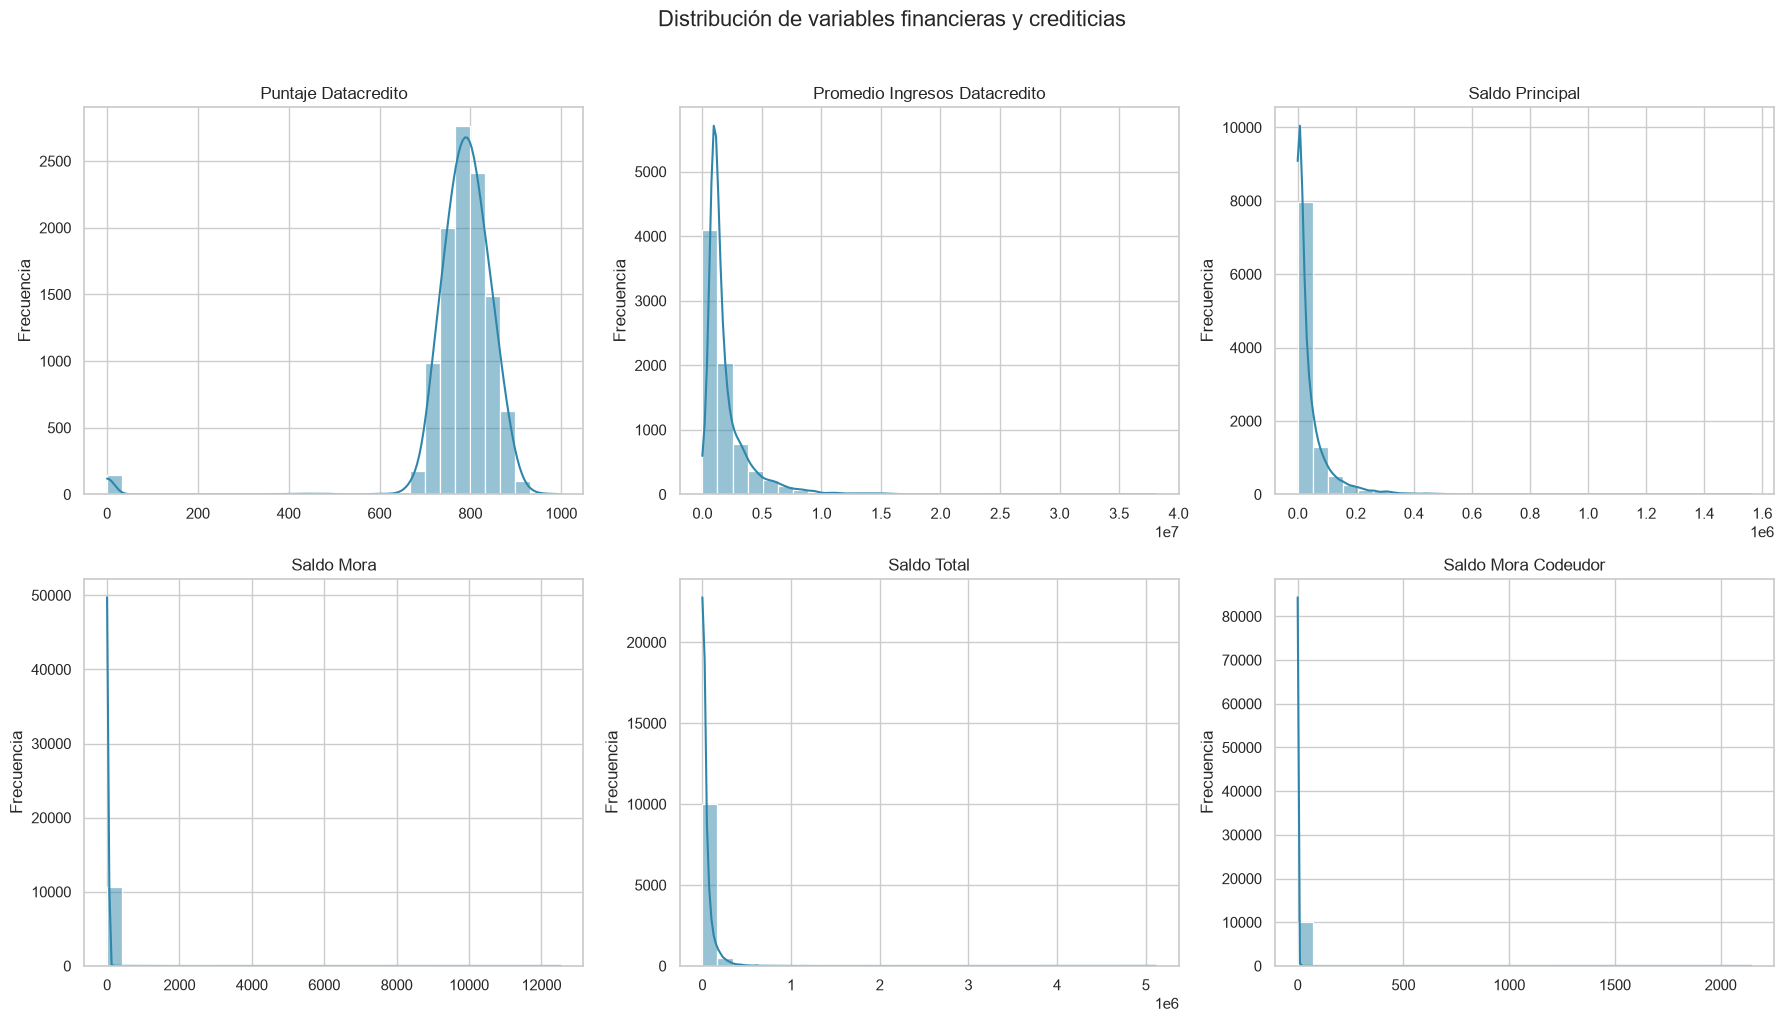

In [43]:
# Distribución de variables numéricas representativas

variables_numericas_representativas = [
    "puntaje_datacredito",
    "promedio_ingresos_datacredito",
    "saldo_principal",
    "saldo_mora",
    "saldo_total",
    "saldo_mora_codeudor"
]

variables_disponibles = [
    columna
    for columna in variables_numericas_representativas
    if columna in df_limpio.columns
]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 10)
)

axes = axes.flatten()

for eje, columna in zip(axes, variables_disponibles):
    sns.histplot(
        data=df_limpio,
        x=columna,
        bins=30,
        kde=True,
        ax=eje,
        color="#2E86AB"
    )

    eje.set_title(
        columna.replace("_", " ").title()
    )
    eje.set_xlabel("")
    eje.set_ylabel("Frecuencia")

for eje in axes[len(variables_disponibles):]:
    eje.set_visible(False)

plt.suptitle(
    "Distribución de variables financieras y crediticias",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### 4.1 Interpretación de las distribuciones numéricas

Las variables analizadas presentan comportamientos diferenciados. `puntaje_datacredito` muestra una distribución aproximadamente unimodal, concentrada principalmente alrededor de los valores altos de la escala. Los registros con puntaje igual a cero aparecen aislados de la distribución principal y, de acuerdo con el análisis previo, serán tratados durante el modelado como una probable codificación de información no disponible.

Las variables monetarias presentan una marcada asimetría positiva. La mayoría de los registros se concentra en valores bajos o intermedios, mientras que una cantidad reducida alcanza importes considerablemente elevados. Este comportamiento es especialmente visible en `promedio_ingresos_datacredito`, `saldo_principal` y `saldo_total`.

En `saldo_mora` y `saldo_mora_codeudor` existe además una fuerte concentración en cero, consistente con la ausencia de deuda vencida para una proporción importante de los clientes. Estos ceros se conservarán como valores válidos.

La asimetría observada indica que la media puede verse afectada por valores extremos. Por ello, durante el modelado se priorizarán estrategias robustas de imputación y se evaluarán transformaciones logarítmicas para las variables monetarias. Los valores elevados no serán eliminados automáticamente, ya que pueden representar situaciones financieras reales y aportar información predictiva.

## 5. Análisis de la variable objetivo

La variable `Pago_atiempo` representa el resultado que se buscará predecir. Antes de analizar su relación con las variables explicativas, se examinará la frecuencia de cada clase para determinar si existe desbalance y seleccionar posteriormente métricas de evaluación apropiadas.

,Pago_atiempo,cantidad,porcentaje
0,1,10252,95.25
1,0,511,4.75


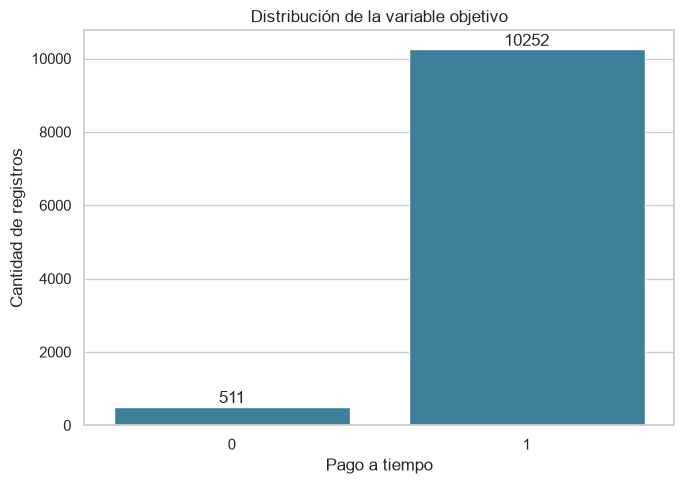

In [44]:
# Distribución de la variable objetivo

distribucion_objetivo = (
    df_limpio["Pago_atiempo"]
    .value_counts(dropna=False)
    .rename_axis("Pago_atiempo")
    .reset_index(name="cantidad")
)

distribucion_objetivo["porcentaje"] = (
    distribucion_objetivo["cantidad"]
    / len(df_limpio)
    * 100
).round(2)

display(distribucion_objetivo)

plt.figure(figsize=(7, 5))

eje = sns.countplot(
    data=df_limpio,
    x="Pago_atiempo",
    color="#2E86AB"
)

for contenedor in eje.containers:
    eje.bar_label(contenedor)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Pago a tiempo")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

### 5.1 Interpretación de la distribución de la variable objetivo

La variable objetivo presenta un desbalance considerable. De los 10.763 registros analizados, 10.252 corresponden a clientes que pagaron a tiempo, equivalentes al 95,25 %, mientras que solamente 511 registros, el 4,75 %, corresponden a clientes que no pagaron a tiempo.

Este desbalance implica que la exactitud no será suficiente para evaluar los modelos. Un clasificador que asignara todos los casos a la clase mayoritaria alcanzaría una exactitud del 95,25 % sin detectar ningún incumplimiento.

Desde la perspectiva del negocio, la clase minoritaria es especialmente relevante porque representa a los clientes que no pagaron a tiempo. Por ello, durante el modelado se deberá evaluar específicamente la capacidad para identificar esta clase mediante métricas como recall, precisión, F1-score, ROC-AUC y PR-AUC, además de utilizar una matriz de confusión.

Como `Pago_atiempo = 0` representa el evento de interés, antes del entrenamiento se construirá una variable objetivo operativa denominada `incumplimiento`, en la cual el valor 1 representará que el cliente no pagó a tiempo. Esta recodificación facilitará la interpretación de las métricas sin modificar el significado original de la variable.

La división entre entrenamiento y prueba se realizará de forma estratificada para conservar aproximadamente la proporción de ambas clases. Las estrategias adicionales para manejar el desbalance se implementarán únicamente sobre los datos de entrenamiento.

## 6. Análisis bivariado respecto de la variable objetivo

Para identificar posibles diferencias entre los clientes que pagan y los que no pagan a tiempo, se compararán las principales variables financieras y crediticias según la clase objetivo.

Debido al fuerte desbalance y a la asimetría de las variables monetarias, se utilizarán medianas como medida descriptiva principal. Estas comparaciones tienen un propósito exploratorio y no implican por sí mismas relaciones causales.

In [45]:
# Comparación de variables numéricas según Pago_atiempo

variables_bivariadas = [
    "puntaje_datacredito",
    "promedio_ingresos_datacredito",
    "saldo_principal",
    "saldo_mora",
    "saldo_total",
    "saldo_mora_codeudor"
]

resumen_bivariado_numerico = (
    df_limpio
    .groupby("Pago_atiempo")[variables_bivariadas]
    .median()
    .round(2)
    .T
    .rename(
        columns={
            0: "Mediana_no_pago_a_tiempo",
            1: "Mediana_pago_a_tiempo"
        }
    )
)

resumen_bivariado_numerico["diferencia_absoluta"] = (
    resumen_bivariado_numerico["Mediana_no_pago_a_tiempo"]
    - resumen_bivariado_numerico["Mediana_pago_a_tiempo"]
).round(2)

resumen_bivariado_numerico["diferencia_porcentual"] = (
    resumen_bivariado_numerico["diferencia_absoluta"]
    / resumen_bivariado_numerico[
        "Mediana_pago_a_tiempo"
    ].replace(0, np.nan)
    * 100
).round(2)

display(resumen_bivariado_numerico)

Pago_atiempo,Mediana_no_pago_a_tiempo,Mediana_pago_a_tiempo,diferencia_absoluta,diferencia_porcentual
puntaje_datacredito,768.0,792.0,-24.0,-3.03
promedio_ingresos_datacredito,1052529.0,1211296.0,-158767.0,-13.11
saldo_principal,13110.0,14492.5,-1382.5,-9.54
saldo_mora,0.0,0.0,0.0,NaN
saldo_total,14518.5,16308.0,-1789.5,-10.97
saldo_mora_codeudor,0.0,0.0,0.0,NaN


### 6.1 Comparación de las variables numéricas según el pago

La comparación muestra que los clientes que no pagaron a tiempo presentan medianas inferiores en varias características financieras y crediticias.

La mediana de `puntaje_datacredito` es de 768 puntos entre quienes no pagaron a tiempo y de 792 entre quienes sí lo hicieron, lo que representa una diferencia de 24 puntos. También se observa que el grupo con incumplimiento presenta una mediana de ingresos 13,11 % menor, un saldo principal 9,54 % menor y un saldo total 10,97 % menor.

Estas diferencias sugieren que un menor puntaje y una menor capacidad financiera podrían estar asociados con una mayor probabilidad de incumplimiento. Sin embargo, las diferencias observadas son moderadas y no deben interpretarse como relaciones causales ni como evidencia suficiente para predecir individualmente el comportamiento de pago.

Las medianas de `saldo_mora` y `saldo_mora_codeudor` son iguales a cero en ambos grupos debido a la elevada concentración de ceros. Por esta razón, la mediana no permite evaluar adecuadamente su posible relación con el objetivo; el modelo podrá aprovechar diferencias en su distribución completa y en la presencia de valores positivos.

En conjunto, ninguna variable numérica parece separar por sí sola las dos clases, por lo que será necesario combinar múltiples atributos mediante modelos supervisados.

## 7. Análisis multivariado

Para examinar conjuntamente las relaciones entre las variables numéricas se utilizará la correlación de Spearman. Esta medida se basa en el orden de los valores y resulta más robusta que la correlación de Pearson frente a distribuciones asimétricas y valores extremos.

Con fines interpretativos, se recodificará temporalmente la variable objetivo como `incumplimiento`, donde 1 representa que el cliente no pagó a tiempo. Esta variable se utilizará únicamente para el análisis y no modificará `Pago_atiempo`.

,correlacion_spearman
puntaje,-0.638926
saldo_mora,0.107989
puntaje_datacredito,-0.090667
huella_consulta,0.072914
promedio_ingresos_datacredito,-0.051454
edad_cliente,-0.050947
capital_prestado,0.041986
cantidad_nulos_pendientes,0.031722
creditos_sectorFinanciero,-0.030280
cantidad_ausencias_detectadas,0.029601


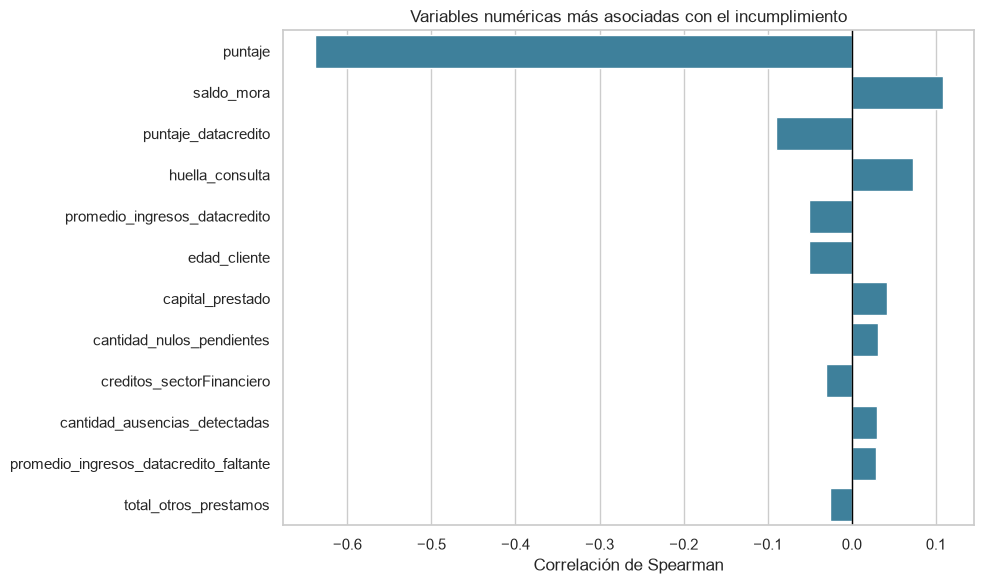

In [46]:
# Correlaciones de Spearman con el incumplimiento

df_correlaciones = df_limpio.copy()

df_correlaciones["incumplimiento"] = (
    1 - df_correlaciones["Pago_atiempo"]
)

columnas_correlacion = (
    df_correlaciones
    .select_dtypes(include=np.number)
    .columns
)

matriz_spearman = (
    df_correlaciones[columnas_correlacion]
    .corr(method="spearman")
)

correlaciones_objetivo = (
    matriz_spearman["incumplimiento"]
    .drop(
        labels=[
            "incumplimiento",
            "Pago_atiempo"
        ],
        errors="ignore"
    )
    .dropna()
    .sort_values(
        key=lambda serie: serie.abs(),
        ascending=False
    )
)

display(
    correlaciones_objetivo
    .head(12)
    .to_frame(name="correlacion_spearman")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=correlaciones_objetivo.head(12).values,
    y=correlaciones_objetivo.head(12).index,
    color="#2E86AB"
)

plt.axvline(0, color="black", linewidth=1)
plt.title("Variables numéricas más asociadas con el incumplimiento")
plt.xlabel("Correlación de Spearman")
plt.ylabel("")
plt.tight_layout()
plt.show()

### 7.1 Asociación de las variables numéricas con el incumplimiento

El análisis de Spearman muestra que `puntaje` es la variable numérica con mayor asociación individual con el incumplimiento. Su correlación es de aproximadamente −0,639, lo que indica que los valores más altos del puntaje se relacionan con una menor frecuencia de incumplimiento.

Esta asociación es considerablemente superior a la observada en las demás variables. Por esta razón, antes del modelado deberá verificarse que `puntaje` esté disponible en el momento en que se realiza la predicción y que no haya sido calculado utilizando el comportamiento de pago que se intenta predecir. Si incorpora información posterior al otorgamiento o al vencimiento, deberá excluirse para evitar fuga de información.

Entre las asociaciones restantes, `saldo_mora` presenta una relación positiva con el incumplimiento, mientras que `puntaje_datacredito` muestra una relación negativa. `huella_consulta` también presenta una asociación positiva, aunque débil.

Las demás correlaciones son de baja magnitud. Esto no implica que las variables carezcan de utilidad predictiva, ya que pueden aportar información mediante interacciones o relaciones no lineales que la correlación individual de Spearman no captura.

En conjunto, el análisis sugiere que el incumplimiento no puede explicarse únicamente mediante relaciones monotónicas simples, con la excepción destacada de `puntaje`. La validez temporal y conceptual de esta variable deberá confirmarse antes de incorporarla al conjunto de predictores.

In [47]:
# Diagnóstico breve de la variable puntaje

resumen_puntaje_objetivo = (
    df_limpio
    .groupby("Pago_atiempo")["puntaje"]
    .agg(
        cantidad="size",
        faltantes=lambda serie: serie.isna().sum(),
        valores_unicos="nunique",
        minimo="min",
        percentil_25=lambda serie: serie.quantile(0.25),
        mediana="median",
        percentil_75=lambda serie: serie.quantile(0.75),
        maximo="max"
    )
    .round(2)
)

display(resumen_puntaje_objetivo)

print(
    "Valores únicos totales de puntaje:",
    df_limpio["puntaje"].nunique(dropna=True)
)

print(
    "Correlación entre puntaje y puntaje_datacredito:",
    round(
        df_limpio[
            ["puntaje", "puntaje_datacredito"]
        ].corr(method="spearman").iloc[0, 1],
        4
    )
)

,cantidad,faltantes,valores_unicos,minimo,percentil_25,mediana,percentil_75,maximo
Pago_atiempo,,,,,,,,
0,511,0,195,-38.01,-3.59,25.42,47.61,62.67
1,10252,0,53,63.81,95.23,95.23,95.23,95.23


Valores únicos totales de puntaje: 248
Correlación entre puntaje y puntaje_datacredito: 0.1195


### 7.2 Evaluación del riesgo de fuga de información en `puntaje`

La distribución de `puntaje` presenta una separación excepcional entre las clases de la variable objetivo. Entre los clientes que no pagaron a tiempo, los valores se encuentran entre −38,01 y 62,67, con una mediana de 25,42. En cambio, entre quienes pagaron a tiempo, el mínimo, los cuartiles, la mediana y el máximo coinciden en 95,23 al redondear a dos decimales.

Aunque existen pequeñas variaciones internas, esta concentración indica que `puntaje` contiene información estrechamente relacionada con el resultado que se busca predecir. Además, su correlación con `puntaje_datacredito` es solamente 0,1195, por lo que ambas variables no parecen representar el mismo indicador.

Los archivos disponibles no incluyen un diccionario de datos ni permiten verificar cómo y cuándo se calcula `puntaje`. En estas condiciones, no puede garantizarse que la variable esté disponible antes de conocer el comportamiento de pago.

Por criterio conservador, `puntaje` será excluida del conjunto principal de predictores para evitar una posible fuga de información y obtener una estimación más realista del desempeño del modelo. La columna se conservará en el conjunto limpio para mantener la trazabilidad, pero no ingresará al pipeline de entrenamiento.

## 8. Conclusiones generales del EDA

El análisis exploratorio permitió comprender la estructura del conjunto de datos, identificar problemas de calidad y establecer las decisiones que deberán implementarse durante el modelado.

La variable objetivo presenta un desbalance considerable: el 95,25 % de los registros corresponde a pagos realizados a tiempo y solamente el 4,75 % representa incumplimientos. En consecuencia, la exactitud no será una métrica suficiente. La evaluación deberá priorizar la detección de la clase minoritaria mediante recall, precisión, F1-score, ROC-AUC, PR-AUC y matriz de confusión.

Las variables monetarias muestran distribuciones fuertemente asimétricas y valores extremos. Estos registros no se eliminarán automáticamente, ya que pueden representar situaciones financieras reales. Las imputaciones se realizarán mediante estrategias robustas aprendidas exclusivamente con el conjunto de entrenamiento y se evaluarán transformaciones logarítmicas cuando resulten apropiadas.

Los valores faltantes no responden a un único mecanismo. En algunas variables representan ausencia estructural de información financiera, mientras que en otras aparecen de forma específica. Por ello, se conservarán indicadores de ausencia y se evitará interpretar todos los faltantes como valores iguales a cero.

El análisis bivariado mostró que los clientes que no pagaron a tiempo presentan, en términos generales, menores medianas de puntaje de Datacrédito, ingresos y saldos principales. Sin embargo, las diferencias individuales son moderadas y ninguna de estas variables separa por sí sola las clases.

La variable `puntaje` presenta una separación excepcional respecto de `Pago_atiempo`. Debido a que no existe documentación que permita verificar su origen y disponibilidad temporal, será excluida del conjunto principal de predictores por riesgo de fuga de información.

Para el modelado se recodificará el evento de interés como `incumplimiento = 1`, se realizará una división estratificada entre entrenamiento y prueba y todas las transformaciones se aprenderán exclusivamente con los datos de entrenamiento. Las estrategias frente al desbalance también se aplicarán únicamente dentro del proceso de entrenamiento.

Con estas decisiones se da por finalizado el análisis exploratorio de datos.

In [49]:
# Verificación de los tipos no contemplados

columnas_revisar = [
    "fecha_prestamo",
    "tendencia_ingresos"
]

display(
    X[columnas_revisar]
    .dtypes
    .to_frame(name="tipo_de_dato")
)

for columna in columnas_revisar:
    print(f"\nValores de ejemplo de {columna}:")
    print(X[columna].dropna().head(10).tolist())

,tipo_de_dato
fecha_prestamo,datetime64[us]
tendencia_ingresos,string



Valores de ejemplo de fecha_prestamo:
[Timestamp('2024-12-21 11:31:35'), Timestamp('2025-04-22 09:47:35'), Timestamp('2026-01-08 12:22:40'), Timestamp('2025-08-04 12:04:10'), Timestamp('2025-04-26 11:24:26'), Timestamp('2025-06-10 08:54:01'), Timestamp('2025-08-09 13:00:44'), Timestamp('2025-08-18 12:49:19'), Timestamp('2025-05-30 09:11:18'), Timestamp('2024-12-31 14:32:59')]

Valores de ejemplo de tendencia_ingresos:
['Estable', 'Creciente', 'Sin información', 'Creciente', 'Creciente', 'Creciente', 'Creciente', 'Creciente', 'Creciente', 'Creciente']


In [55]:
# Recarga del módulo después de las modificaciones

import importlib
import ft_engineering

importlib.reload(ft_engineering)

from ft_engineering import (
    separar_variables_objetivo,
    aplicar_reglas_especificas,
    identificar_tipos_columnas
)

# Separación de predictores y objetivo
X, y = separar_variables_objetivo(df_limpio)

# Aplicación de reglas previas:
# - puntaje_datacredito = 0 pasa a NaN
# - fecha_prestamo se transforma en variables temporales
X_transformado = aplicar_reglas_especificas(X)

# Identificación de tipos después de crear las variables temporales
columnas_numericas, columnas_categoricas = (
    identificar_tipos_columnas(X_transformado)
)

print("Dimensiones de X original:", X.shape)
print("Dimensiones de X transformado:", X_transformado.shape)
print("Dimensiones de y:", y.shape)

print(
    "\n¿fecha_prestamo permanece?:",
    "fecha_prestamo" in X_transformado.columns
)

print(
    "¿tendencia_ingresos es categórica?:",
    "tendencia_ingresos" in columnas_categoricas
)

print("\nCaracterísticas temporales creadas:")
print([
    columna
    for columna in X_transformado.columns
    if columna.startswith("prestamo_")
])

print("\nCantidad de columnas numéricas:", len(columnas_numericas))
print("Cantidad de columnas categóricas:", len(columnas_categoricas))

Dimensiones de X original: (10763, 33)
Dimensiones de X transformado: (10763, 36)
Dimensiones de y: (10763,)

¿fecha_prestamo permanece?: False
¿tendencia_ingresos es categórica?: True

Características temporales creadas:
['prestamo_anio', 'prestamo_mes', 'prestamo_dia_semana', 'prestamo_hora']

Cantidad de columnas numéricas: 33
Cantidad de columnas categóricas: 3


In [56]:
# División de los datos antes de ajustar el preprocesamiento

from sklearn.model_selection import train_test_split

from ft_engineering import construir_pipeline_preprocesamiento


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Las columnas se identificaron sobre los datos después
# de aplicar las reglas específicas
X_train_transformado = aplicar_reglas_especificas(X_train)

columnas_numericas, columnas_categoricas = (
    identificar_tipos_columnas(X_train_transformado)
)


# Construcción y ajuste solamente con entrenamiento
pipeline_preprocesamiento = construir_pipeline_preprocesamiento(
    columnas_numericas=columnas_numericas,
    columnas_categoricas=columnas_categoricas
)

X_train_preprocesado = pipeline_preprocesamiento.fit_transform(
    X_train
)

X_test_preprocesado = pipeline_preprocesamiento.transform(
    X_test
)


print("X_train original:", X_train.shape)
print("X_test original:", X_test.shape)

print(
    "\nX_train preprocesado:",
    X_train_preprocesado.shape
)

print(
    "X_test preprocesado:",
    X_test_preprocesado.shape
)

print(
    "\nValores faltantes en entrenamiento:",
    np.isnan(X_train_preprocesado).sum()
)

print(
    "Valores faltantes en prueba:",
    np.isnan(X_test_preprocesado).sum()
)

print(
    "\nDistribución relativa de y_train:"
)

display(
    y_train.value_counts(normalize=True)
    .sort_index()
    .rename("proporción")
    .to_frame()
)

print(
    "\nDistribución relativa de y_test:"
)

display(
    y_test.value_counts(normalize=True)
    .sort_index()
    .rename("proporción")
    .to_frame()
)

X_train original: (8610, 33)
X_test original: (2153, 33)

X_train preprocesado: (8610, 50)
X_test preprocesado: (2153, 50)

Valores faltantes en entrenamiento: 0
Valores faltantes en prueba: 0

Distribución relativa de y_train:


,proporción
incumplimiento,
0,0.952497
1,0.047503



Distribución relativa de y_test:


,proporción
incumplimiento,
0,0.952624
1,0.047376


In [57]:
# Recuperación y verificación de los nombres de las características

nombres_caracteristicas = (
    pipeline_preprocesamiento
    .named_steps["preprocesador"]
    .get_feature_names_out()
)

print(
    "Cantidad de nombres recuperados:",
    len(nombres_caracteristicas)
)

print(
    "Cantidad de columnas preprocesadas:",
    X_train_preprocesado.shape[1]
)

print("\nNombres de las características:")
print(nombres_caracteristicas)


# Conversión de las matrices en DataFrames

X_train_preprocesado = pd.DataFrame(
    X_train_preprocesado,
    columns=nombres_caracteristicas,
    index=X_train.index
)

X_test_preprocesado = pd.DataFrame(
    X_test_preprocesado,
    columns=nombres_caracteristicas,
    index=X_test.index
)


print(
    "\nTipo de X_train preprocesado:",
    type(X_train_preprocesado)
)

print(
    "Tipo de X_test preprocesado:",
    type(X_test_preprocesado)
)

display(X_train_preprocesado.head())

Cantidad de nombres recuperados: 50
Cantidad de columnas preprocesadas: 50

Nombres de las características:
['tipo_credito' 'capital_prestado' 'plazo_meses' 'edad_cliente'
 'salario_cliente' 'total_otros_prestamos' 'cuota_pactada'
 'puntaje_datacredito' 'cant_creditosvigentes' 'huella_consulta'
 'saldo_mora' 'saldo_total' 'saldo_principal' 'saldo_mora_codeudor'
 'creditos_sectorFinanciero' 'creditos_sectorCooperativo'
 'creditos_sectorReal' 'promedio_ingresos_datacredito'
 'cantidad_ausencias_detectadas' 'tendencia_ingresos_faltante'
 'promedio_ingresos_datacredito_faltante' 'saldo_mora_codeudor_faltante'
 'saldo_principal_faltante' 'saldo_mora_faltante' 'saldo_total_faltante'
 'puntaje_datacredito_faltante' 'puntaje_datacredito_cero'
 'puntaje_datacredito_invalido' 'cantidad_nulos_pendientes'
 'prestamo_anio' 'prestamo_mes' 'prestamo_dia_semana' 'prestamo_hora'
 'tipo_laboral_Empleado' 'tipo_laboral_Independiente'
 'tendencia_ingresos_Creciente' 'tendencia_ingresos_Decreciente'
 'tend

,tipo_credito,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,cantidad_ausencias_detectadas,tendencia_ingresos_faltante,promedio_ingresos_datacredito_faltante,saldo_mora_codeudor_faltante,saldo_principal_faltante,saldo_mora_faltante,saldo_total_faltante,puntaje_datacredito_faltante,puntaje_datacredito_cero,puntaje_datacredito_invalido,cantidad_nulos_pendientes,prestamo_anio,prestamo_mes,prestamo_dia_semana,prestamo_hora,tipo_laboral_Empleado,tipo_laboral_Independiente,tendencia_ingresos_Creciente,tendencia_ingresos_Decreciente,tendencia_ingresos_Estable,tendencia_ingresos_Sin información,patron_ausencia_Patrón 1,patron_ausencia_Patrón 11,patron_ausencia_Patrón 12,patron_ausencia_Patrón 2,patron_ausencia_Patrón 3,patron_ausencia_Patrón 4,patron_ausencia_Patrón 5,patron_ausencia_Patrón 6,patron_ausencia_Patrón 7,patron_ausencia_Patrón 8,patron_ausencia_Patrón 9
8118,0.0,1.676423,0.333333,-0.75,0.332773,0.870667,1.368448,-0.500000,0.0,-0.5,0.0,0.638391,-0.046421,0.0,0.000000,0.0,0.5,10.422982,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,-0.25,-0.6,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6360,0.0,-0.150673,0.333333,-0.10,-0.177007,-0.200000,-0.328511,-0.803030,-0.6,0.5,0.0,-0.321901,-0.335544,0.0,-0.333333,0.0,-0.5,-0.378501,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.166667,-0.75,0.4,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3905,1.0,3.625296,0.166667,-0.05,2.467475,5.636000,3.084228,0.257576,0.6,0.0,0.0,4.636709,5.465768,0.0,1.333333,0.0,0.0,0.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.166667,0.25,-0.2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4371,0.0,0.099404,-0.666667,0.10,0.106204,0.000000,0.765137,0.636364,0.2,0.0,0.0,1.165287,0.083287,0.0,1.000000,0.0,0.0,3.672042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0,1.166667,0.25,0.4,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7109,1.0,0.784645,0.000000,4.00,216.318839,45.839772,0.612884,0.000000,-1.0,-1.0,0.0,0.000000,0.000000,0.0,-0.666667,0.0,-0.5,0.000000,3.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,5.0,0.0,-0.166667,0.50,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [54]:
# Verificación de indicadores de ausencia potencialmente duplicados

pares_indicadores = [
    (
        "puntaje_datacredito_faltante",
        "missingindicator_puntaje_datacredito"
    ),
    (
        "saldo_mora_faltante",
        "missingindicator_saldo_mora"
    ),
    (
        "saldo_total_faltante",
        "missingindicator_saldo_total"
    ),
    (
        "saldo_principal_faltante",
        "missingindicator_saldo_principal"
    ),
    (
        "saldo_mora_codeudor_faltante",
        "missingindicator_saldo_mora_codeudor"
    ),
    (
        "promedio_ingresos_datacredito_faltante",
        "missingindicator_promedio_ingresos_datacredito"
    )
]

for indicador_existente, indicador_imputador in pares_indicadores:
    son_iguales = X_train_preprocesado[
        indicador_existente
    ].equals(
        X_train_preprocesado[indicador_imputador]
    )

    print(
        f"{indicador_existente} == "
        f"{indicador_imputador}: {son_iguales}"
    )

puntaje_datacredito_faltante == missingindicator_puntaje_datacredito: False
saldo_mora_faltante == missingindicator_saldo_mora: True
saldo_total_faltante == missingindicator_saldo_total: True
saldo_principal_faltante == missingindicator_saldo_principal: True
saldo_mora_codeudor_faltante == missingindicator_saldo_mora_codeudor: True
promedio_ingresos_datacredito_faltante == missingindicator_promedio_ingresos_datacredito: True
